# Automated promoter library redesign

這本 notebook 從 high-throughput PKL database 選取元件，不進行 de novo sequence generation。

每個 element 的 pooling 邊界由 `CONFIG.mutable_energy_fraction_ranges` 逐元素指定，形式是
`(lower_fraction, upper_fraction, n_bins)` —— 在該元素自己的觀測 min–max energy 軸上，
要納入哪一段、切成幾個等寬 bin。**每個 bin 各出一個 mutable 版本**，所以 N 個 bin 給出
`v1..vN`；`CONFIG.consensus` 每個 element 可以放**一條或多條** locked 序列，由弱到強依序填在
`v{N+1}` 之後的槽位，且 `v1..vN` 必須全部弱於**最弱的那一條** locked。

目前 UP 鎖了兩條（`v4 = TGGACTGATATATACAAAA`、`v5 = TAAAAAATTTGGAAAATAG`）因此只切 3 個 bin，
其餘元素各鎖一條、切 4 個 bin —— 每個 element 都仍是 5 個版本，所以文庫維持 `5^6 = 15,625`。

Spacer 是例外：`Spacer_v2` 來自 bin 2，`Spacer_v3 = Spacer_v2[:-2] + "TG"`（衍生而非取自 bin 3），
兩者是同一個 coupled design unit，所以 spacer 至少要 3 個 bin。

每個 design state 組合成 `∏(N_e + L_e)` variants（`L_e` = 該元素 locked 條數）；六個元素都是 5 個版本時就是
`5^6 = 15,625`（Batch 0 會把實際數字印出來）。使用固定且最大程度均勻的 64 種 3-bp gaps，
再由 CorePromoter clean model 掃描最佳 register。

Validation（驗收標準，兩個 anchor 一致）：

- `shift != 0` 就計入 shifted variant。
- m10 shifted rate 與 m35 shifted rate 都必須 `< max_shift_rate`（10%）。
- 所有 shifted variants 都必須在 `-2..+2 bp`；任何 `abs(shift) > 2` 都不通過。
- 只有當下 phase 的 objective 嚴格改善才接受 replacement。

Phase 排程（**驗收線與階段切換點是兩件事**）：

`CONFIG.m10_phase_exit_rate`（預設 20%）只是**切換階段的觸發點**，不是驗收線。搜尋因此是三段式，
而不是把 m10 一路壓到 10% 才碰 -35：

1. **m10 階段** —— m10 shifted rate `> 20%` 時。Objective 依序是
   `(m10 偏移數, m35 偏移數, 超界數, m10 最大絕對偏移, m35 最大絕對偏移)`。
2. **m35 修正階段** —— m10 已 `<= 20%` 而 m35 尚未達標時。Objective 改成
   `(m35 偏移數, m10 偏移數, 超界數, m35 最大絕對偏移, m10 最大絕對偏移)`，
   **m35 排第一**，所以「只降 m10 卻讓 m35 變差」的提案不再獲勝；
   同時加上一條 hard constraint：**提案的 m10 偏移數不得高於當前值（可以相等）**。
   m35 持平但 m10 下降的提案仍算改善並會被接受，免費的 m10 進步不會被丟掉。
3. **回頭補 m10** —— m35 已達標但 m10 還沒到 10% 時，phase 自動回到 m10 繼續壓。

m10 偏移數在階段 1、3 是 objective 首鍵（因此非遞增），在階段 2 被 hard constraint 擋住，
所以整個搜尋期間 **m10 偏移數單調不增**，階段來回不會無限震盪。把
`m10_phase_exit_rate` 設成等於 `max_shift_rate` 就大致回到原本單向的 m10 → m35 流程，
差別只在兩個邊界：閘門用 `<=` 且不看超界，所以 rate 恰好落在門檻上、或已低於門檻但仍有
`|shift| > 2` 時，新版會進 m35 階段，舊版的 `m10_validation_pass` 檢查則不會。


In [ ]:
# === Path bootstrap (shared by 01-07) ===
# Locates MS2_Data_PyTorch/scripts/library_release by walking up from the cwd,
# then imports _paths, which sets every other path absolutely and puts
# MS2_Data_PyTorch/scripts on sys.path. Safe to run from any working directory.
import sys
from pathlib import Path

for _c in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    _rel = _c / "MS2_Data_PyTorch" / "scripts" / "library_release"
    if (_rel / "_paths.py").exists():
        if str(_rel) not in sys.path:
            sys.path.insert(0, str(_rel))
        break
else:
    raise RuntimeError(f"library_release not found from {Path.cwd()}")

from _paths import *  # noqa: F401,F403

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATA_DIR     :", DATA_DIR)
print("RELEASE_OUT  :", RELEASE_OUT)


In [12]:
# === Batch 0: setup and editable design config ===
import importlib
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import automated_promoter_library_design as r
importlib.reload(r)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")


# Shared reporting helpers, used by both Batch 4 (initial) and Batch 7 (final).
def shift_summary_table(summary):
    """Per-anchor view of a summarize_validation() result."""
    return pd.DataFrame([
        {
            "anchor": anchor,
            "shifted_count": summary[f"{anchor}_shifted_count"],
            "shifted_rate": summary[f"{anchor}_shifted_rate"],
            "out_of_range_count": summary[f"{anchor}_out_of_range_count"],
            "max_abs_shift": summary[f"{anchor}_max_abs_shift"],
            "pass": summary[f"{anchor}_validation_pass"],
        }
        for anchor in ("m10", "m35")
    ])


def phase_status_line(summary):
    """One-line view of where the phase schedule currently stands."""
    return (
        f"phase={summary['phase']} | "
        f"m10 gate (<= {CONFIG.m10_phase_exit_rate:.0%}) "
        f"{'open' if summary['m10_phase_gate_pass'] else 'closed'} | "
        f"m10 {summary['m10_shifted_rate']:.2%} pass={summary['m10_validation_pass']} | "
        f"m35 {summary['m35_shifted_rate']:.2%} pass={summary['m35_validation_pass']} | "
        f"global pass={summary['global_validation_pass']}"
    )


def plot_shift_distributions(scan, title_prefix=""):
    """Two-panel m10/m35 shift histogram. English-only labels for VSCode stability."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), dpi=140)
    for ax, anchor in zip(axes, ("m10", "m35")):
        counts = scan[f"{anchor}_shift"].value_counts().sort_index()
        ax.bar(counts.index.astype(int), counts.values, color="#4C72B0")
        ax.set_title(f"{title_prefix}{anchor} shift distribution")
        ax.set_xlabel("Shift (bp)")
        ax.set_ylabel("Variant count")
    plt.tight_layout()
    plt.show()


def plot_version_uniformity(scan, title_prefix=""):
    """Per element-version, how many variants survive with shift == 0.

    The acceptance criterion this library is judged on: every version of every
    element should be represented about equally among the variants whose designed
    architecture is the one the model actually reads. A version that drops to zero
    breaks the factorial - that level simply has no clean variants to analyse - and
    that failure is invisible in the aggregate shift rate. The binding constraint
    sits at each element's weak end, because a weak designed promoter is the case
    an off-target site wins.

    Role mirrors plot_shift_distributions: call once on initial_scan and once on
    result.final_scan (title_prefix="Final ").
    """
    clean = scan[(scan["m10_shift"] == 0) & (scan["m35_shift"] == 0)]
    labels, counts, boundaries = [], [], []
    for element in r.ELEMENTS:
        for version in sorted(scan[f"{element}_version"].unique(), key=r.version_index):
            labels.append(f"{element}\n{version}")
            counts.append(int((clean[f"{element}_version"] == version).sum()))
        boundaries.append(len(counts) - 0.5)

    fig, ax = plt.subplots(figsize=(14, 4.2), dpi=140)
    positions = np.arange(len(counts))
    ax.bar(positions, counts, color="#4C72B0", width=0.74, zorder=3)
    # Perfectly uniform = the clean library split evenly across an element's
    # versions. Every element here has 5, so one line serves all six panels.
    uniform = len(clean) / 5
    ax.axhline(uniform, color="#C44E52", ls="--", lw=1.3, zorder=4)
    ax.text(len(counts) - 0.4, uniform, f"  uniform = {uniform:,.0f}",
            color="#C44E52", fontsize=8, va="center", ha="left")
    for boundary in boundaries[:-1]:
        ax.axvline(boundary, color="0.85", lw=1.0, zorder=1)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=7.5)
    ax.set_xlim(-0.7, len(counts) - 0.3)
    ax.set_ylabel("variants with shift == 0")
    worst = min(counts) / uniform if uniform else float("nan")
    ax.set_title(f"{title_prefix}element-version representation in the non-shifted "
                 f"library    clean = {len(clean):,} of {len(scan):,} "
                 f"({len(clean) / len(scan) * 100:.1f}%)    "
                 f"worst version = {worst * 100:.0f}% of uniform")
    ax.grid(axis="y", color="0.85", lw=0.6, alpha=0.6, zorder=0)
    plt.tight_layout()
    suffix = (title_prefix.strip().lower() or "initial").replace(" ", "_")
    for ext in ("png", "svg"):
        fig.savefig(OUT_DIR / f"version_uniformity_{suffix}.{ext}", bbox_inches="tight")
    plt.show()


def plot_element_version_energy_distributions(scan, score_col, title_prefix="", n_bins=60):
    """Six-panel per-element version energy histogram, layered over the whole-library
    baseline. Each panel is paired with a whole-model predicted-GFP sigmoid panel
    above it that shares the same x-axis: score_col is a full-sequence CorePromoter
    energy, and the scanner already ran it through the whole model's
    energy2expression() to get design_predicted_log10_gfp / best_predicted_log10_gfp,
    so that column is a deterministic function of score_col alone (not of element or
    version) - scattering all 15,625 variants therefore traces the exact sigmoid
    rather than an approximation. Role mirrors plot_shift_distributions: call once on
    initial_scan and once on result.final_scan (title_prefix="Final ") to compare
    before/after redesign.
    """
    if not score_col.endswith("_core_score"):
        raise ValueError(f"score_col must end with '_core_score', got {score_col!r}")
    gfp_col = score_col.replace("_core_score", "_predicted_log10_gfp")

    baseline = scan[score_col].to_numpy(dtype=float)
    baseline_gfp = scan[gfp_col].to_numpy(dtype=float)
    edges = np.histogram_bin_edges(baseline, bins=n_bins)
    version_colors = ["#C44E52", "#DD8452", "#55A868", "#4C72B0", "#8172B2"]
    sigmoid_color = "#333333"
    # Same LogGFP=1/4 training-filter markers as scatter_with_marginals in
    # Library_energy_vs_LogGFP.ipynb.
    gfp_ref_lines = (1.0, 4.0)

    fig = plt.figure(figsize=(16.5, 10.0), dpi=140)
    outer = fig.add_gridspec(2, 3, hspace=0.24, wspace=0.22,
                              top=0.91, bottom=0.055, left=0.035, right=0.99)

    for idx, element in enumerate(r.ELEMENTS):
        row, col = divmod(idx, 3)
        inner = outer[row, col].subgridspec(2, 1, height_ratios=(1.0, 3.2), hspace=0.06)
        ax_top = fig.add_subplot(inner[0])
        ax = fig.add_subplot(inner[1], sharex=ax_top)

        ax_top.scatter(baseline, baseline_gfp, s=3, alpha=0.5, color=sigmoid_color,
                        edgecolors="none", zorder=2)
        for value in gfp_ref_lines:
            if baseline_gfp.min() < value < baseline_gfp.max():
                ax_top.axhline(value, color="0.65", ls=":", lw=0.9, zorder=1)
        ax_top.set_ylabel("Predicted\nlog10 GFP", fontsize=8)
        ax_top.set_title(f"{title_prefix}{element}")
        ax_top.tick_params(labelbottom=False, labelsize=7)

        ax.hist(baseline, bins=edges, color="0.75", alpha=0.6, zorder=1,
                 label="All 15,625 variants")

        version_col = f"{element}_version"
        versions = sorted(scan[version_col].unique(), key=r.version_index)
        locked = set(CONFIG.locked_versions(element))
        for version, color in zip(versions, version_colors):
            subset = scan.loc[scan[version_col] == version, score_col].to_numpy(dtype=float)
            label = f"{version} (locked)" if version in locked else version
            ax.hist(subset, bins=edges, histtype="step", linewidth=1.7,
                     color=color, zorder=2, label=label)

        ax.set_xlabel(f"{score_col} (higher = stronger)")
        ax.set_ylabel("Variant count")
        ax.legend(fontsize=7, loc="upper left")

    fig.suptitle(f"{title_prefix}Full-sequence {score_col} by element version",
                 fontsize=18, y=1.01)

    suffix = (title_prefix.strip().lower() or "initial").replace(" ", "_")
    for ext in ("png", "svg"):
        fig.savefig(OUT_DIR / f"element_version_energy_distributions_{suffix}_{score_col}.{ext}",
                    bbox_inches="tight")
    plt.show()


def plot_element_positions(elements, scored_pools, config, title_prefix=""):
    """Batch-0.5-style per-element energy distribution, with `elements`' v1..v5
    sequence energies marked. Pass result.final_elements (title_prefix="Final ")
    or initial_elements for the pre-redesign picture.
    """
    version_colors = ["#C44E52", "#DD8452", "#55A868", "#4C72B0", "#8172B2"]
    n_hist_bins = 80
    fig, axes = plt.subplots(2, 3, figsize=(16.5, 8.6), dpi=140)

    for ax, element in zip(axes.ravel(), r.ELEMENTS):
        pool = scored_pools[element]
        energy = pool["energy"].to_numpy(dtype=float)
        edges, e_min, e_max, span, frac_lo, frac_hi, n_bins = r.pool_bin_edges(pool)

        rows = elements.loc[elements["element"] == element].sort_values(
            "version", key=lambda s: s.map(r.version_index)
        )
        locked = set(config.locked_versions(element))

        if frac_lo > 0.0:
            ax.axvspan(e_min, edges[0], color="0.82", alpha=0.6, zorder=0,
                       label="Outside binned range")
        if frac_hi < 1.0:
            ax.axvspan(edges[-1], e_max, color="0.82", alpha=0.6, zorder=0,
                       label=None if frac_lo > 0.0 else "Outside binned range")
        ax.axvspan(edges[0], edges[-1], color="#4C72B0", alpha=0.07, zorder=0,
                   label="Binned range")

        ax.hist(energy, bins=n_hist_bins, color="#4C72B0", zorder=2)
        for i, edge in enumerate(edges):
            ax.axvline(edge, color="0.30", ls="--", lw=0.9, zorder=3,
                       label="Current bin edge" if i == 0 else None)

        for (_, row), color in zip(rows.iterrows(), version_colors):
            # label= feeds the one shared cross-panel legend below, so keep it
            # plain (v1..v5 always mean the same color everywhere); "(locked)"
            # varies per element (UP locks v4+v5, the rest only v5) and belongs
            # on the per-panel line text instead, not the shared legend.
            ax.axvline(row["energy"], color=color, lw=1.8, zorder=4, label=row["version"])
            text = f"{row['version']} (locked)" if row["version"] in locked else row["version"]
            ax.text(row["energy"], 0.98, text, transform=ax.get_xaxis_transform(),
                    ha="right", va="top", fontsize=8, color=color, rotation=90)

        bin_counts = (
            pool["energy_bin"].dropna().astype(int).value_counts()
            .reindex(range(1, n_bins + 1), fill_value=0).astype(int)
        )
        top = max(int(np.histogram(energy, bins=n_hist_bins)[0].max()), 1)
        ax.set_yscale("log")
        ax.set_ylim(0.7, top * 10 ** 0.60)
        label_y = top * 10 ** 0.14
        for bin_id, lo, hi in zip(range(1, n_bins + 1), edges[:-1], edges[1:]):
            ax.text((lo + hi) / 2.0, label_y, f"bin {bin_id}\n{bin_counts[bin_id]:,}",
                    ha="center", va="bottom", fontsize=9, color="0.25", zorder=5,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75))

        view_lo = min([e_min, *rows["energy"]])
        view_hi = max([e_max, *rows["energy"]])
        pad = 0.02 * (view_hi - view_lo)
        ax.set_xlim(view_lo - pad, view_hi + pad)
        ax.set_title(
            f"{element}   n = {len(pool):,}   |   {n_bins} bins over fraction {frac_lo:.2f}-{frac_hi:.2f}",
            fontsize=12, pad=20,
        )
        sec = ax.secondary_xaxis(
            "top",
            functions=(lambda e, o=e_min, s=span: (e - o) / s,
                       lambda f, o=e_min, s=span: o + f * s),
        )
        sec.tick_params(labelsize=12, pad=1)

    handles, labels = [], []
    for ax in axes.ravel():
        for handle, label in zip(*ax.get_legend_handles_labels()):
            if label not in labels:
                handles.append(handle)
                labels.append(label)

    fig.suptitle(f"{title_prefix}Selected v1-v5 positions within each element's energy pool",
                 fontsize=22, y=0.995)
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.95),
               ncol=min(len(labels), 9), frameon=False, fontsize=11)
    fig.supxlabel("Element model energy, higher = stronger (per-panel scale). "
                  "Top axis = energy_fraction 0-1.", fontsize=14)
    fig.supylabel("Sequence count (log10)", fontsize=16)
    fig.tight_layout(rect=(0.012, 0.015, 1, 0.905))

    suffix = (title_prefix.strip().lower() or "current").replace(" ", "_")
    for ext in ("png", "svg"):
        fig.savefig(OUT_DIR / f"element_positions_{suffix}.{ext}", bbox_inches="tight")
    plt.show()


# Select the frozen whole/CorePromoter checkpoint used for full-sequence scanning.
CORE_MODEL_VARIANT = "baseline"  # "baseline" or "tss_pas"
CORE_MODEL_CHECKPOINTS = {
    "baseline": r.WEIGHTS_DIR / "weights_CorePromoter_clean.pt",
    "tss_pas": r.WEIGHTS_DIR / "weights_CorePromoter_tss_pas.pt",
}
CORE_MODEL_CHECKPOINT = CORE_MODEL_CHECKPOINTS[CORE_MODEL_VARIANT]
if not CORE_MODEL_CHECKPOINT.exists():
    raise FileNotFoundError(
        f"Missing {CORE_MODEL_VARIANT} checkpoint: {CORE_MODEL_CHECKPOINT}. "
        "Run Model_CorePromoter_TSS_pretrain.ipynb first."
    )

# RUN_MODE = "new": create a new output directory.
# RUN_MODE = "resume": continue an existing directory from its checkpoint/final_elements.
# NOTE: RESUME_DIR below must point at a directory that exists before switching
# back to "resume" - Batch 0 raises otherwise.
RUN_MODE = "new"  # "new" or "resume"
RESUME_DIR = r.DEFAULT_PARENT_OUT / "automated_redesign_20260813_205625"

if RUN_MODE == "new":
    OUT_DIR = r.DEFAULT_PARENT_OUT / f"automated_redesign_{RUN_STAMP}"
elif RUN_MODE == "resume":
    OUT_DIR = Path(RESUME_DIR)
    if not OUT_DIR.exists():
        raise FileNotFoundError(f"Resume directory does not exist: {OUT_DIR}")
else:
    raise ValueError(f"RUN_MODE must be 'new' or 'resume', not {RUN_MODE!r}")

CACHE_DIR = r.PROJECT_ROOT / "outputs" / "energy_bin_cache"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Edit these sequences when the locked consensus changes.
# One string = one locked slot. A list = several locked slots, weakest first,
# filling the versions above the last mutable bin. UP therefore locks v4 and v5
# and only bins v1-v3; every other element keeps its single locked slot.
CONSENSUS = {
    "UP": ["TGGACTGATATATACAAAA", "CTAATCGGGGGCGATTAAG"],
    "m35": "TTGACA",
    "spacer": "TATGGCGCAAAATGGGG",
    "m10": "TATAAT",
    "DIS": "TTTTATTA",
    "ITS": "CAAAAAAAAG",
}
# "UP": ["TGGACTGATATATACAAAA", "CTAATCGGGGGCGATTAAG"],
# "UP": ["TGGACTGATATATACAAAA", "TAAAAAATTTGGAAAATAG"],

# Per-element pooling boundary, as (lower_fraction, upper_fraction, n_bins) on that
# element's own observed min-max energy axis. Read the fractions straight off the
# Batch 0.5 top axis.
#
# Every bin becomes one mutable version, so N bins give v1..vN plus the locked
# consensus at v{N+1}, and one design state assembles prod(N_e + 1) variants.
# All six at 4 bins -> 5^6 = 15,625, printed below so an edit shows up immediately.
#
# Tune the lower bound to trade weak-sequence coverage against register stability,
# and the upper bound against the locked consensus: v1..vN must all be weaker than
# it, so a bin above the red v5 line in Batch 0.5 has no eligible sequence and
# DesignSpace raises instead of silently picking from a neighbouring bin.
# The spacer needs at least 3 bins because Spacer_v3 = Spacer_v2[:-2] + "TG" is
# derived rather than drawn from bin 3.
ENERGY_BIN_RANGES = {
    # 3 bins, not 4: UP's two locked sequences take v4 and v5, so it still has
    # 5 versions in total and the library stays at 5^6 = 15,625.
    "UP":     (0.0, 0.7, 3),
    "m35":    (0.2, 1.0, 4),
    "spacer": (0.0, 0.9, 4),
    "m10":    (0.0, 1.0, 4),
    "DIS":    (0.0, 1.0, 4),
    "ITS":    (0.0, 1.0, 4),
}

CONFIG = r.DesignConfig(
    consensus=CONSENSUS,
    bg5="CCCTTTCGTCTTCACACAGCAGCAGTCAGGTAGGGAAGAGACC",
    bg3="GTCGACTCTAGA",
    gap_length=3,
    gap_seed=777,
    n_energy_bins=4,  # fallback bin count for any element omitted from the dict below
    mutable_energy_fraction_ranges=ENERGY_BIN_RANGES,
    max_candidates_per_unit=500,
    max_abs_shift=2,
    # Acceptance threshold for BOTH anchors. Unchanged by the phase schedule.
    max_shift_rate=0.10,
    # Phase-switch trigger only. Once m10 is at or below this, the search moves on
    # to the -35 correction phase instead of driving m10 all the way to
    # max_shift_rate first; it returns to m10 after m35 passes. Must be >=
    # max_shift_rate; setting it equal gives back the original single-pass flow
    # except at the threshold itself and while |shift| > 2 variants remain.
    m10_phase_exit_rate=0.20,
    scan_batch_size=15625,
    require_derived_spacer_in_database=False,
    # Drop candidates that never cleared the assay detection limit. Below linear
    # GFP 6 a variant simply did not fluoresce, so its LogGFP says nothing about
    # how weak the element is - and those would otherwise define the weak end of
    # the ladder. PL.pkl (the -35/-10 source) is 90.3% below the limit.
    #
    # min_bright_measurements is clipped per sequence to the rows it actually has,
    # which is what lets one rule cover both pool shapes: a PL hexamer appears in
    # 19-25 rows paired with different partners and must clear the limit in 5 of
    # them, while UL/SL17/DL/ITS give each sequence exactly one row and the rule
    # becomes "its own measurement was bright". Set detection_limit_gfp=None to
    # restore the unfiltered pools.
    #
    # Retention: UP 100%, spacer 100%, DIS 100%, ITS 95.2%, m35 73.5%, m10 41.5%.
    # Watch m10 v1 - the filter leaves it only 17 candidates.
    detection_limit_gfp=6.0,
    min_bright_measurements=5,
)

USE_CACHE = True
MAX_SOURCE_ROWS = None  # None = use all observed sequences in each PKL

SEARCH_SETTINGS = {
    # This is an additional iteration allowance for each new/resume execution.
    "max_iterations": 50,
    "n_driver_units": 3,
    "probe_candidates_per_unit": 2,
    "pair_beam_width": 6,
    "max_pair_evaluations": 8,
    "max_stalled_iterations": 60,
}

config_filename = "run_config.json" if RUN_MODE == "new" else f"resume_config_{RUN_STAMP}.json"
r.save_run_config(
    OUT_DIR, CONFIG, SEARCH_SETTINGS, DEVICE,
    core_model_checkpoint=CORE_MODEL_CHECKPOINT,
    filename=config_filename,
)
print("Run mode:", RUN_MODE)
print("Project root:", r.PROJECT_ROOT)
print("Device:", DEVICE)
print("Output:", OUT_DIR)
print("Core model variant:", CORE_MODEL_VARIANT)
print("Core model checkpoint:", CORE_MODEL_CHECKPOINT)
print()
print("Energy bins and versions per element:")
for element in r.ELEMENTS:
    n_bins, lower, upper, mode = CONFIG.energy_bin_spec(element)
    print(f"  {element:7s} fraction {lower:.2f}-{upper:.2f} into {n_bins} bins"
          f"  ->  mutable {', '.join(CONFIG.mutable_versions(element))}"
          f"  + locked {', '.join(CONFIG.locked_versions(element))}   [{mode}]")
print()
print("Locked sequences (never touched by the search):")
for element in r.ELEMENTS:
    for version, seq in CONFIG.locked_sequences(element).items():
        print(f"  {element:7s} {version}  {seq}")
print("Variants per design state:", f"{CONFIG.n_variants():,}",
      "=", " x ".join(str(len(CONFIG.versions_for(e))) for e in r.ELEMENTS))
print()
print("Phase schedule:")
print(f"  validation (both anchors): shifted rate < {CONFIG.max_shift_rate:.0%}"
      f" and no |shift| > {CONFIG.max_abs_shift} bp")
print(f"  m10 phase   while m10 shifted rate  > {CONFIG.m10_phase_exit_rate:.0%}")
print(f"  m35 phase   once m10 shifted rate  <= {CONFIG.m10_phase_exit_rate:.0%};"
      " m10 shifted count may not rise, m35 leads the objective")
print(f"  back to m10 once m35 passes but m10 is still >= {CONFIG.max_shift_rate:.0%}")

Run mode: new
Project root: c:\project\comprolib\Whole-model
Device: cpu
Output: c:\project\comprolib\Whole-model\outputs\019ec8ae-c0ac-7190-868c-5c4ba74a5396\automated_redesign_20260820_132630
Core model variant: baseline
Core model checkpoint: c:\project\comprolib\Whole-model\MS2_Data_PyTorch\weights\weights_CorePromoter_clean.pt

Energy bins and versions per element:
  UP      fraction 0.00-0.70 into 3 bins  ->  mutable v1, v2, v3  + locked v4, v5   [custom_mutable_range]
  m35     fraction 0.20-1.00 into 4 bins  ->  mutable v1, v2, v3, v4  + locked v5   [custom_mutable_range]
  spacer  fraction 0.00-0.90 into 4 bins  ->  mutable v1, v2, v3, v4  + locked v5   [custom_mutable_range]
  m10     fraction 0.00-1.00 into 4 bins  ->  mutable v1, v2, v3, v4  + locked v5   [custom_mutable_range]
  DIS     fraction 0.00-1.00 into 4 bins  ->  mutable v1, v2, v3, v4  + locked v5   [custom_mutable_range]
  ITS     fraction 0.00-1.00 into 4 bins  ->  mutable v1, v2, v3, v4  + locked v5   [custom_

## Batch 0.5: 六個文庫的能量分布與現行 pooling 邊界

在 Batch 1 真正切 bin 之前，先看清楚每個文庫的能量分布長什麼樣，用來決定 Batch 0 的
`ENERGY_BIN_RANGES` 每個元素該填什麼。

每個元素的邊界是 `(lower_fraction, upper_fraction, n_bins)`，**每個 bin 各出一個 mutable
版本**（N 個 bin → `v1..vN` + locked `v{N+1}`）。等寬切法對這些分布並不友善：實測全部六個
文庫都嚴重集中，能量全距的兩端非常稀疏。以 spacer 為例，0–0.8 這段切 4 份的計數是
`32,020 / 246,556 / 53,186 / 1,751` —— 相差兩個數量級，而 0.8–1.0 那段整段只有 52 條；
ITS 的 bin 3 一個人吃掉 511,415 條。這就是為什麼邊界要逐元素看圖決定，而不是統一切全距。

這個 cell 建立的 `element_models` / `scored_pools` / `bin_summary` 會被後面所有 batch 直接
沿用（Batch 1 起不再重建），所以直方圖的橫軸與實際切 bin 的軸是**同一把尺**，不是另外算一套。
畫圖用的 bin 邊界也是呼叫 module 的 `r.pool_bin_edges()`，與 `assign_equal_width_bins`
實際切 bin 用的是同一個 `_bin_edges()`。

每個 panel（順序 UP → -35 → spacer 17 → -10 → DIS → ITS）：

- **橫軸** = 該 element model 算出的 energy（higher = stronger）。**每個 panel 各自縮放**，
  不同 element 的分數不可互相比較。上緣副軸是 `energy_fraction` 0–1，也就是要填進
  `ENERGY_BIN_RANGES` 的那個尺度 —— 可以直接從圖上讀出邊界該設多少。
- **縱軸** = 序列數。計數的是**去重後、長度與 ACGT 都合規**的序列，也就是實際進入
  pooling 的那個 pool 的筆數，不是文庫的 read count。預設 log10 軸，否則稀疏尾巴看不見；
  把 `LOG_COUNTS` 改成 `False` 可看原始線性計數。
- **灰色虛線** = 現行 bin 邊界，上緣標出每個 bin 實際裝到幾條序列。
- **淺藍色區塊** = 目前納入切 bin 的能量範圍；灰底區塊是被 `lower/upper_fraction` 排除掉的
  部分（預設下 UP/spacer/DIS/ITS 是 0.8–1.0，m35/m10 是 0–0.3 與 0.9–1.0）。
- **紅線** = locked 序列的能量，每個 locked 槽位一條。實線是**最弱的那一條**（binding），
  虛線是其餘的。因為 mutable 版本的 hard constraint 是「必須弱於所有 locked」，實線那條才是
  真正決定 `upper_fraction` 能拉到哪的界線：**任何超過實線的 bin 都會抓不到候選而讓 Batch 2
  直接報錯**。表格的 `n_eligible_below_locked` 就是該 bin 扣掉這個限制後真正剩下的條數。
  UP 有兩條紅線（v4 實線、v5 虛線），因為 v5 比 v4 強，binding 的是 v4。

> 幾個一眼可見的陷阱：UP 的紅線在 fraction 0.726，所以 `upper_fraction` 拉到 0.8 以上就開始
> 出現無效 bin（原本 0–1 切 5 份的 bin 5 正是 `n_eligible_below_v5 = 0`）；spacer 的 consensus
> 甚至落在 pool 之外（fraction 1.085，比 SL17 最強的序列還強），m35/m10/DIS 的 consensus 剛好
> 就是 pool 最大值（fraction 1.000）。

-35 / -10 的能量取自 `Model_PL.ipynb` 從 `PL.pkl` 做出來的 BPM 模型
（`BPM/Params_Con17.pkl`，取負號轉成 higher-is-stronger），這正是 pooling 實際用的軸。
`weights_minus35.pt` / `weights_minus10.pt` 雖然在 `weights/` 裡，但 pipeline 沒有任何
code 載入它們（`ElementModelBundle._load_all` 明確跳過），而且與 BPM 排序嚴重不一致
（Spearman ρ = 0.37 / −0.22），所以這裡不使用。

輸出的 `energy_bin_summary.csv` 是整個 run 唯一一份 per-bin 計數表（含 `pct_of_pool`）。


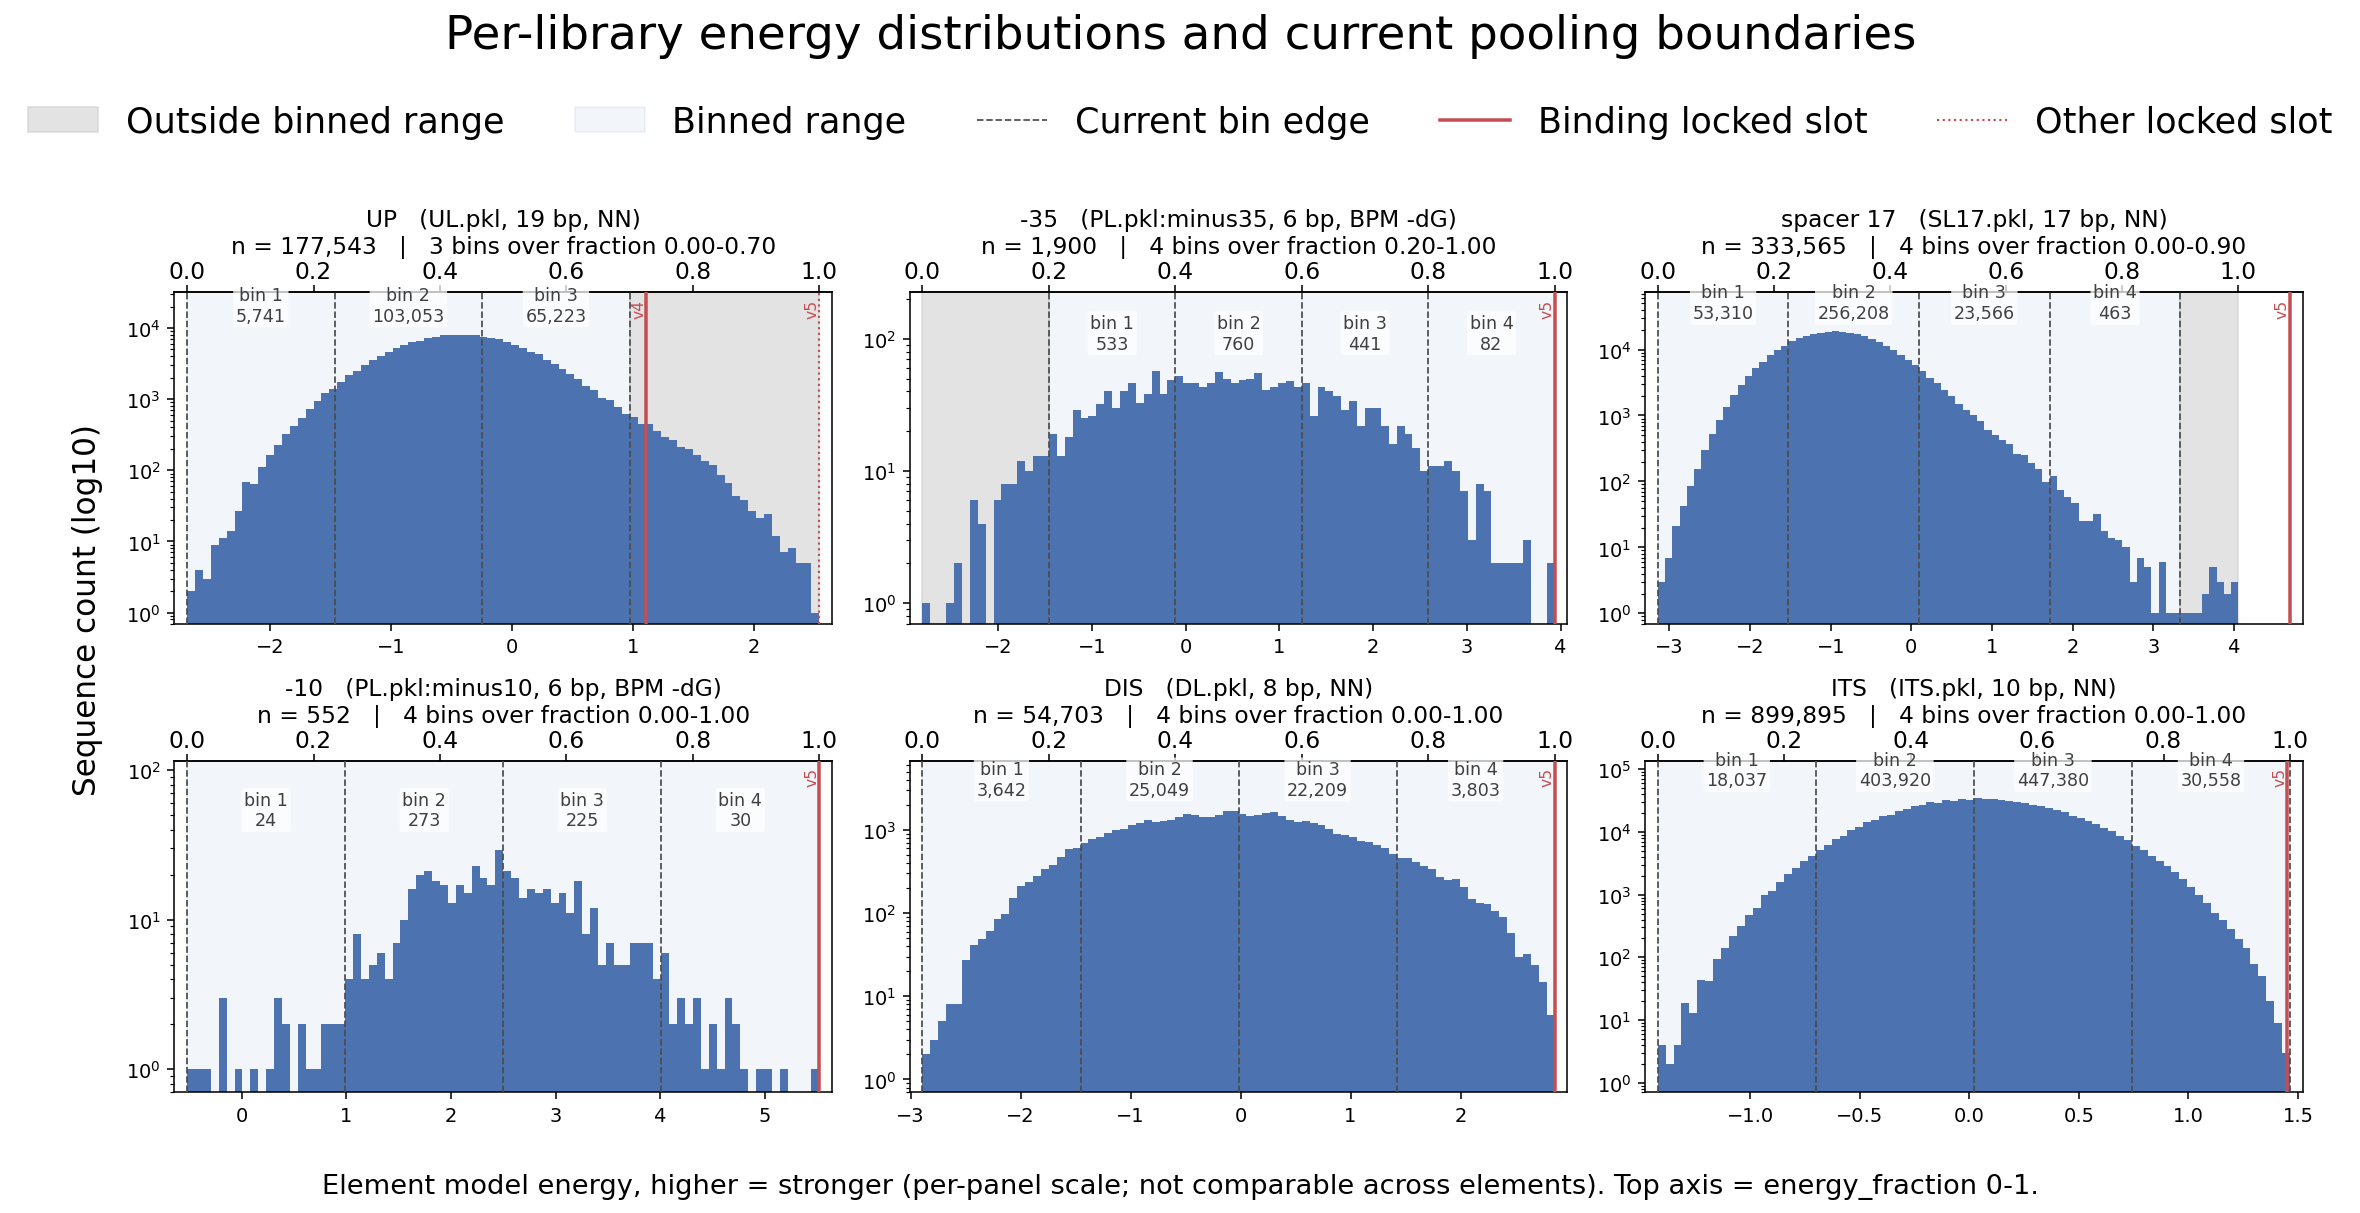

,element,source,n_sequences,energy_min,p1,p25,median,p75,p99,energy_max,...,fraction_upper,range_energy_lower,range_energy_upper,n_inside_range,frac_inside_range,locked_versions,binding_locked_version,binding_locked_energy,binding_locked_fraction,n_below_binding_locked
0,UP,"UL.pkl, 19 bp, NN",177543,-2.6862,-1.7289,-0.8004,-0.4130,-0.0202,1.2268,2.5404,...,0.7,-2.6862,0.9724,174017,0.9801,v4=1.1085;v5=2.5404,v4,1.1085,0.7260,175057
1,m35,"PL.pkl:minus35, 6 bp, BPM -dG",1900,-2.8114,-1.9754,-0.3604,0.4737,1.3267,3.1873,3.9375,...,1.0,-1.4616,3.9375,1816,0.9558,v5=3.9375,v5,3.9375,1.0000,1899
2,spacer,"SL17.pkl, 17 bp, NN",333565,-3.1436,-2.2425,-1.3320,-0.9097,-0.4723,0.9045,4.0523,...,0.9,-3.1436,3.3327,333547,0.9999,v5=4.6918,v5,4.6918,1.0889,333565
3,m10,"PL.pkl:minus10, 6 bp, BPM -dG",552,-0.5199,-0.0896,1.8568,2.4431,3.0445,4.7210,5.5199,...,1.0,-0.5199,5.5199,552,1.0000,v5=5.5199,v5,5.5199,1.0000,552
4,DIS,"DL.pkl, 8 bp, NN",54703,-2.8922,-2.0240,-0.7427,-0.0750,0.5912,2.1756,2.8561,...,1.0,-2.8922,2.8561,54703,1.0000,v5=2.8561,v5,2.8561,1.0000,54702
5,ITS,"ITS.pkl, 10 bp, NN",899895,-1.4213,-0.7918,-0.2057,0.0503,0.3107,0.9205,1.4638,...,1.0,-1.4213,1.4638,899895,1.0000,v5=1.4523,v5,1.4523,0.9960,899894


,element,energy_bin,binning_mode,energy_fraction_lower,energy_fraction_upper,energy_lower,energy_upper,n_sequences,n_eligible_below_locked,n_excluded_below_range,n_excluded_above_range,binding_locked_version,binding_locked_energy,locked_energies,pct_of_pool
0,UP,1,custom_mutable_range,0.0000,0.2333,-2.6862,-1.4666,5741,5741,0,3526,v4,1.1085,v4=1.1085;v5=2.5404,3.2336
1,UP,2,custom_mutable_range,0.2333,0.4667,-1.4666,-0.2471,103053,103053,0,3526,v4,1.1085,v4=1.1085;v5=2.5404,58.0440
2,UP,3,custom_mutable_range,0.4667,0.7000,-0.2471,0.9724,65223,65223,0,3526,v4,1.1085,v4=1.1085;v5=2.5404,36.7365
3,m35,1,custom_mutable_range,0.2000,0.4000,-1.4616,-0.1119,533,533,84,0,v5,3.9375,v5=3.9375,28.0526
4,m35,2,custom_mutable_range,0.4000,0.6000,-0.1119,1.2379,760,760,84,0,v5,3.9375,v5=3.9375,40.0000
5,m35,3,custom_mutable_range,0.6000,0.8000,1.2379,2.5877,441,441,84,0,v5,3.9375,v5=3.9375,23.2105
6,m35,4,custom_mutable_range,0.8000,1.0000,2.5877,3.9375,82,81,84,0,v5,3.9375,v5=3.9375,4.3158
7,spacer,1,custom_mutable_range,0.0000,0.2250,-3.1436,-1.5245,53310,53310,0,18,v5,4.6918,v5=4.6918,15.9819
8,spacer,2,custom_mutable_range,0.2250,0.4500,-1.5245,0.0946,256208,256208,0,18,v5,4.6918,v5=4.6918,76.8090
9,spacer,3,custom_mutable_range,0.4500,0.6750,0.0946,1.7137,23566,23566,0,18,v5,4.6918,v5=4.6918,7.0649


Figure and tables written to: c:\project\comprolib\Whole-model\outputs\019ec8ae-c0ac-7190-868c-5c4ba74a5396\automated_redesign_20260820_132630


In [13]:
# === Batch 0.5: per-library energy distributions and current pooling boundaries ===
# English-only plot labels for VSCode/Jupyter rendering stability.
import numpy as np

# log10 y axis. The spacer pool puts 246,556 sequences in bin 2 and only 52 in
# bin 5, so a linear axis hides exactly the sparse tails the boundary decision
# depends on. Set False to read raw linear counts.
LOG_COUNTS = True
SHOW_FRACTION_AXIS = True   # top axis = energy_fraction, the scale that
                            # CONFIG.mutable_energy_fraction_ranges is written in
N_HIST_BINS = 80

PANEL_LABELS = {"UP": "UP", "m35": "-35", "spacer": "spacer 17",
                "m10": "-10", "DIS": "DIS", "ITS": "ITS"}
# -35/-10 come from the BPM model that Model_PL.ipynb derives from PL.pkl
# (BPM/Params_Con17.pkl), negated to a higher-is-stronger axis. The orphaned
# weights_minus35.pt / weights_minus10.pt are deliberately not used here:
# nothing in the pipeline loads them and they disagree with BPM
# (Spearman rho = 0.37 / -0.22), so they cannot explain the bins below.
PANEL_NOTES = {
    "UP": "UL.pkl, 19 bp, NN",
    "m35": "PL.pkl:minus35, 6 bp, BPM -dG",
    "spacer": "SL17.pkl, 17 bp, NN",
    "m10": "PL.pkl:minus10, 6 bp, BPM -dG",
    "DIS": "DL.pkl, 8 bp, NN",
    "ITS": "ITS.pkl, 10 bp, NN",
}

# Built once here and reused by every later batch, so the histogram and the bins
# it diagnoses share one score axis. build_scored_pools caches on file signatures.
element_models = r.ElementModelBundle(DEVICE)
scored_pools = r.build_scored_pools(
    models=element_models,
    config=CONFIG,
    cache_dir=CACHE_DIR,
    use_cache=USE_CACHE,
    max_source_rows=MAX_SOURCE_ROWS,
)
bin_summary = r.energy_bin_summary(scored_pools, CONFIG, element_models)

stats_rows = []
fig, axes = plt.subplots(2, 3, figsize=(16.5, 8.6), dpi=140)

for ax, element in zip(axes.ravel(), r.ELEMENTS):
    pool = scored_pools[element]
    energy = pool["energy"].to_numpy(dtype=float)
    edges, e_min, e_max, span, frac_lo, frac_hi, n_bins = r.pool_bin_edges(pool)
    # "v4=1.1085;v5=1.3915" -> {"v4": 1.1085, "v5": 1.3915}
    locked_spec = bin_summary.loc[bin_summary["element"] == element, "locked_energies"].iloc[0]
    locked_e = {k: float(v) for k, v in (t.split("=") for t in str(locked_spec).split(";"))}
    # Mutable candidates must clear the weakest locked slot, so that is the line
    # the bin edges actually have to stay under.
    bind_v = min(locked_e, key=locked_e.get)
    v_bind = locked_e[bind_v]

    # lower_fraction > 0 leaves out-of-range sequences with <NA> energy_bin.
    bin_counts = (
        pool["energy_bin"].dropna().astype(int).value_counts()
        .reindex(range(1, n_bins + 1), fill_value=0).astype(int)
    )

    if frac_lo > 0.0:
        ax.axvspan(e_min, edges[0], color="0.82", alpha=0.6, zorder=0,
                   label="Outside binned range")
    if frac_hi < 1.0:
        ax.axvspan(edges[-1], e_max, color="0.82", alpha=0.6, zorder=0,
                   label=None if frac_lo > 0.0 else "Outside binned range")
    ax.axvspan(edges[0], edges[-1], color="#4C72B0", alpha=0.07, zorder=0,
               label="Binned range")

    ax.hist(energy, bins=N_HIST_BINS, color="#4C72B0", zorder=2)
    for i, edge in enumerate(edges):
        ax.axvline(edge, color="0.30", ls="--", lw=0.9, zorder=3,
                   label="Current bin edge" if i == 0 else None)
    for i, (lv, le) in enumerate(sorted(locked_e.items(), key=lambda kv: kv[1])):
        ax.axvline(le, color="#C44E52", lw=1.8 if lv == bind_v else 1.1,
                   ls="-" if lv == bind_v else ":", zorder=4,
                   label="Binding locked slot" if i == 0 else
                         ("Other locked slot" if i == 1 else None))
        ax.text(le, 0.98, lv, transform=ax.get_xaxis_transform(), ha="right",
                va="top", fontsize=8, color="#C44E52", rotation=90)

    # Headroom above the tallest histogram bar for the per-bin count labels.
    top = max(int(np.histogram(energy, bins=N_HIST_BINS)[0].max()), 1)
    if LOG_COUNTS:
        ax.set_yscale("log")
        ax.set_ylim(0.7, top * 10 ** 0.60)
        label_y = top * 10 ** 0.14
    else:
        ax.set_ylim(0, top * 1.32)
        label_y = top * 1.14
    for bin_id, lo, hi in zip(range(1, n_bins + 1), edges[:-1], edges[1:]):
        # The white backing keeps the v5 line from cutting through the number.
        ax.text((lo + hi) / 2.0, label_y, f"bin {bin_id}\n{bin_counts[bin_id]:,}",
                ha="center", va="bottom", fontsize=9, color="0.25", zorder=5,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75))

    # A locked sequence can sit outside the observed pool range - the spacer
    # consensus scores 4.66 while the strongest sequence in SL17.pkl only reaches
    # 4.05 - so widen the view to keep those lines visible instead of clipping.
    view_lo = min([e_min, *locked_e.values()])
    view_hi = max([e_max, *locked_e.values()])
    pad = 0.02 * (view_hi - view_lo)
    ax.set_xlim(view_lo - pad, view_hi + pad)
    ax.set_title(
        f"{PANEL_LABELS[element]}   ({PANEL_NOTES[element]})\n"
        f"n = {len(pool):,}   |   {n_bins} bins over fraction {frac_lo:.2f}-{frac_hi:.2f}",
        fontsize=12, pad=20 if SHOW_FRACTION_AXIS else 6,
    )
    if SHOW_FRACTION_AXIS:
        sec = ax.secondary_xaxis(
            "top",
            functions=(lambda e, o=e_min, s=span: (e - o) / s,
                       lambda f, o=e_min, s=span: o + f * s),
        )
        sec.tick_params(labelsize=12, pad=1)

    fraction = (energy - e_min) / span
    inside = (fraction >= frac_lo - 1e-12) & (fraction <= frac_hi + 1e-12)
    p1, p25, p50, p75, p99 = np.percentile(energy, [1, 25, 50, 75, 99])
    stats_rows.append({
        "element": element,
        "source": PANEL_NOTES[element],
        "n_sequences": int(len(energy)),
        "energy_min": e_min, "p1": p1, "p25": p25, "median": p50,
        "p75": p75, "p99": p99, "energy_max": e_max,
        "binning_mode": str(pool["binning_mode"].iloc[0]),
        "n_bins": n_bins,
        "fraction_lower": frac_lo, "fraction_upper": frac_hi,
        "range_energy_lower": float(edges[0]), "range_energy_upper": float(edges[-1]),
        "n_inside_range": int(inside.sum()),
        "frac_inside_range": float(inside.mean()),
        "locked_versions": ";".join(f"{k}={v:.4f}" for k, v in locked_e.items()),
        "binding_locked_version": bind_v,
        "binding_locked_energy": v_bind,
        "binding_locked_fraction": float((v_bind - e_min) / span),
        "n_below_binding_locked": int((energy < v_bind).sum()),
    })

handles, labels = [], []
for ax in axes.ravel():
    for handle, label in zip(*ax.get_legend_handles_labels()):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

fig.suptitle("Per-library energy distributions and current pooling boundaries",
             fontsize=24, y=0.995)
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.945),
           ncol=len(labels), frameon=False, fontsize=18)
fig.supxlabel("Element model energy, higher = stronger "
              "(per-panel scale; not comparable across elements). "
              "Top axis = energy_fraction 0-1.", fontsize=14)
fig.supylabel(f"Sequence count{' (log10)' if LOG_COUNTS else ''}", fontsize=16)
fig.tight_layout(rect=(0.012, 0.015, 1, 0.905))
for ext in ("png", "svg"):
    fig.savefig(OUT_DIR / f"element_energy_distributions.{ext}", bbox_inches="tight")
plt.show()

element_energy_stats = pd.DataFrame(stats_rows)
# The run's only per-bin count table; Batch 1 no longer writes a second copy.
pool_sizes = {element: len(scored_pools[element]) for element in r.ELEMENTS}
bin_summary["pct_of_pool"] = (
    100.0 * bin_summary["n_sequences"] / bin_summary["element"].map(pool_sizes)
)

element_energy_stats.to_csv(OUT_DIR / "element_energy_distribution_stats.csv", index=False)
bin_summary.to_csv(OUT_DIR / "energy_bin_summary.csv", index=False)
display(element_energy_stats.round(4))
display(bin_summary.round(4))
print("Figure and tables written to:", OUT_DIR)


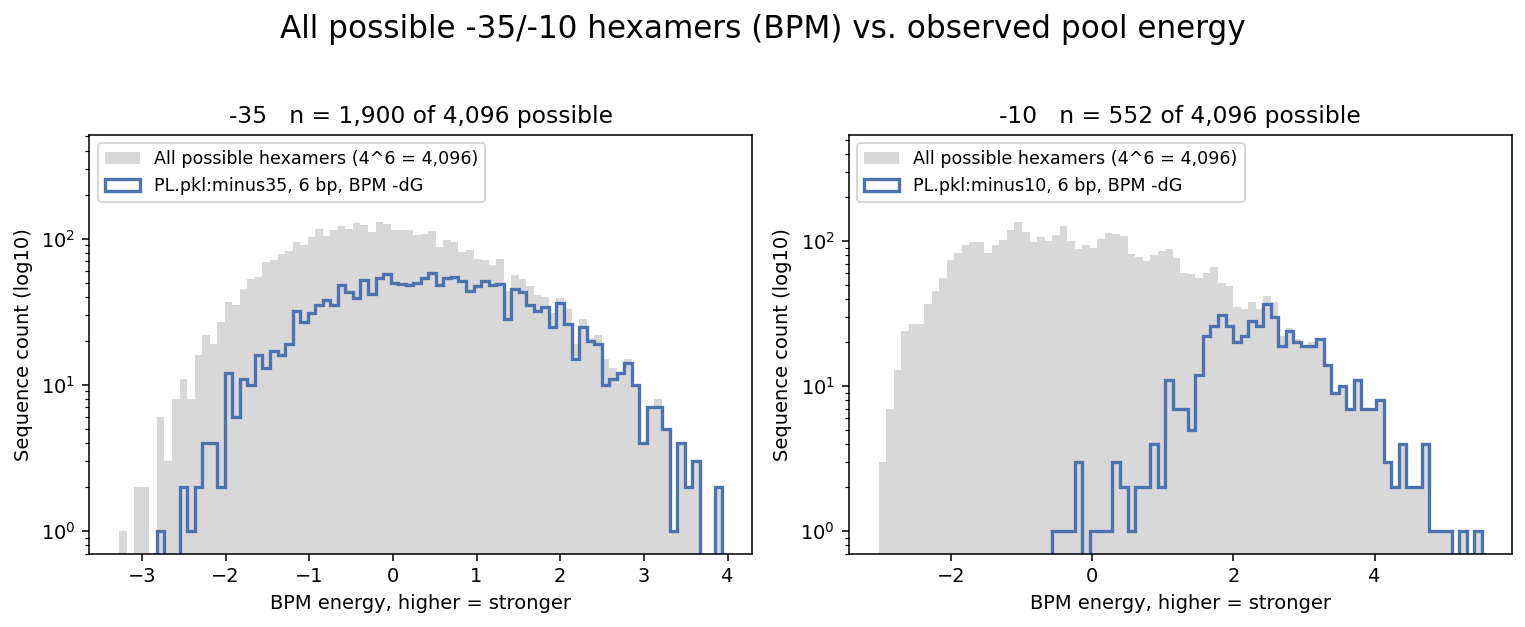

In [14]:
# === Batch 0.5b: all-possible -35/-10 hexamer BPM energies vs. observed pool ===
# English-only plot labels for VSCode/Jupyter rendering stability.
import itertools

HEXAMER_LEN = r.ELEMENT_LENGTHS["m35"]  # == r.ELEMENT_LENGTHS["m10"], both 6 bp
ALL_HEXAMERS = ["".join(p) for p in itertools.product("ACGT", repeat=HEXAMER_LEN)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), dpi=140)
for ax, element in zip(axes, ("m35", "m10")):
    all_energy = element_models.score(element, ALL_HEXAMERS)
    pool_energy = scored_pools[element]["energy"].to_numpy(dtype=float)
    edges = np.histogram_bin_edges(np.concatenate([all_energy, pool_energy]), bins=N_HIST_BINS)

    ax.hist(all_energy, bins=edges, color="0.75", alpha=0.6, zorder=1,
            label=f"All possible hexamers (4^{HEXAMER_LEN} = {len(ALL_HEXAMERS):,})")
    ax.hist(pool_energy, bins=edges, histtype="step", linewidth=1.7,
            color="#4C72B0", zorder=2, label=PANEL_NOTES[element])

    # Headroom above the tallest bar so the upper-left legend doesn't sit on top
    # of the data, same margin convention as the Batch 0.5 panel above.
    top = max(np.histogram(all_energy, bins=edges)[0].max(),
              np.histogram(pool_energy, bins=edges)[0].max(), 1)
    if LOG_COUNTS:
        ax.set_yscale("log")
        ax.set_ylim(0.7, top * 10 ** 0.60)
    else:
        ax.set_ylim(0, top * 1.32)
    ax.set_title(f"{PANEL_LABELS[element]}   n = {len(pool_energy):,} of {len(ALL_HEXAMERS):,} possible")
    ax.set_xlabel("BPM energy, higher = stronger")
    ax.set_ylabel(f"Sequence count{' (log10)' if LOG_COUNTS else ''}")
    ax.legend(fontsize=9, loc="upper left")

fig.suptitle("All possible -35/-10 hexamers (BPM) vs. observed pool energy", fontsize=16, y=1.03)
fig.tight_layout()
for ext in ("png", "svg"):
    fig.savefig(OUT_DIR / f"element_energy_all_hexamers_vs_pool.{ext}", bbox_inches="tight")
plt.show()


## Batch 1: load the full-sequence CorePromoter model

`element_models` / `scored_pools` / `bin_summary` 已經在 Batch 0.5 建好並直接沿用，這裡只補上
掃描整條序列用的 CorePromoter clean model —— 之前這個 cell 會把 element models 與 scored pools
再建一次（重新從硬碟載 5 個 NN checkpoint），那是純粹的重複。

UP/Spacer/DIS/ITS 使用各自已訓練的 element weights。`Model_PL.ipynb` 的 -35/-10 data flow 使用 BPM，因此這兩個元素使用 `-BPM dG` 作為 higher-is-stronger score。不同 element 的分數不可互相比較。

切幾個 bin、切在哪一段，完全由 Batch 0 的 `ENERGY_BIN_RANGES` 決定（見 Batch 0.5 的分布圖）。
`energy_bin_summary` 逐 bin 列出 `n_sequences` 與 `n_eligible_below_locked` —— 後者才是真正可用的
候選數，因為 mutable 版本必須弱於所有 locked 序列（比較對象是 `binding_locked_version` 那一條）；
某個 bin 的 `n_eligible_below_locked` 為 0 時，Batch 2 會直接報錯而不是跨 bin 補候選。

Scored pools 會依 PKL 與 weight/BPM parameter 的檔案 signature 快取；來源或模型更新後會自動重建。改動 bin 邊界不需要重算能量，快取仍然有效。


In [15]:
core_model = r.load_core_model(DEVICE, checkpoint_path=CORE_MODEL_CHECKPOINT)

print("Core model:", CORE_MODEL_CHECKPOINT)
print("Scored pool sizes:", {e: f"{len(scored_pools[e]):,}" for e in r.ELEMENTS})


Core model: c:\project\comprolib\Whole-model\MS2_Data_PyTorch\weights\weights_CorePromoter_clean.pt
Scored pool sizes: {'UP': '177,543', 'm35': '1,900', 'spacer': '333,565', 'm10': '552', 'DIS': '54,703', 'ITS': '899,895'}


## Batch 2: construct database-backed design units

這個步驟執行 hard constraints：

- 一般 element 的 `v1..vN` 必須各自來自對應的 bin 1..N（N = 該元素的 `n_bins`）。
- 所有 mutable 版本的 score 必須低於**每一條** locked 序列，也就是低於 `binding_locked_version`
  （最弱的那一條）。UP 的比較對象是 v4 而不是 v5。
- locked 序列本身逐條核對，被改動就報錯。
- 同一 element 的各條 sequence 不可重複。
- Spacer_v2/v3 必須滿足 coupled rule（v3 = v2[:-2] + "TG"，不取自 bin 3）。
- 任一必要 bin 沒有 eligible sequence 時直接報錯，不跨 bin 補候選 —— 這通常表示該 bin 的上界
  設得比 locked consensus 還強，回 Batch 0 把 `upper_fraction` 調低。


In [16]:
design_space = r.DesignSpace(
    config=CONFIG,
    models=element_models,
    scored_pools=scored_pools,
)

if RUN_MODE == "resume":
    saved_elements_path = OUT_DIR / "current_elements_checkpoint.csv"
    if not saved_elements_path.exists():
        saved_elements_path = OUT_DIR / "final_elements.csv"
    if not saved_elements_path.exists():
        raise FileNotFoundError(f"No resume elements found in {OUT_DIR}")
    initial_elements = pd.read_csv(saved_elements_path)
    initial_state = design_space.state_from_selected_elements(initial_elements)
    print("Recovered state from:", saved_elements_path)
else:
    initial_state = design_space.initial_state()
    initial_elements = design_space.selected_elements(initial_state)

unit_summary = design_space.candidate_pool_summary()

# initial_elements.csv is written by AutomatedRedesigner.run() in Batch 6.
unit_summary.to_csv(OUT_DIR / "design_unit_candidate_counts.csv", index=False)
display(initial_elements)
display(unit_summary)


,element,version,design_unit_id,sequence,energy,energy_bin,selection_mode,locked,in_database
0,DIS,v1,v1,GCGTCGCC,-2.173586,1.0,database_bin,False,True
1,DIS,v2,v2,GGGTAACT,-0.736546,2.0,database_bin,False,True
2,DIS,v3,v3,TAACCATA,0.700437,3.0,database_bin,False,True
3,DIS,v4,v4,TTATCTAG,2.137635,4.0,database_bin,False,True
4,DIS,v5,locked_v5,TTTTATTA,2.856126,4.0,locked_consensus,True,True
5,ITS,v1,v1,GGTCCCCCCC,-1.060627,1.0,database_bin,False,True
6,ITS,v2,v2,CTCGAGCGAC,-0.339370,2.0,database_bin,False,True
7,ITS,v3,v3,CTGTGTCAAG,0.381893,3.0,database_bin,False,True
8,ITS,v4,v4,GAATTAAATG,1.103163,4.0,database_bin,False,True
9,ITS,v5,locked_v5,CAAAAAAAAG,1.452267,4.0,locked_consensus,True,True


,element,design_unit_id,source_energy_bin,energy_fraction_lower,energy_fraction_upper,energy_lower,energy_upper,n_sequences_in_bin,n_eligible_below_locked,binding_locked_version,binding_locked_energy,n_source_candidates_examined,n_candidates_in_search_pool,max_candidates_per_unit,source_pool_was_capped,note
0,DIS,v1,1,0.000000,0.250000,-2.892178,-1.455102,3642,3642,v5,2.856126,500,500,500,True,standard database-backed unit
1,DIS,v2,2,0.250000,0.500000,-1.455102,-0.018026,25049,25049,v5,2.856126,500,500,500,True,standard database-backed unit
2,DIS,v3,3,0.500000,0.750000,-0.018026,1.419050,22209,22209,v5,2.856126,500,500,500,True,standard database-backed unit
3,DIS,v4,4,0.750000,1.000000,1.419050,2.856126,3803,3802,v5,2.856126,500,500,500,True,standard database-backed unit
4,ITS,v1,1,0.000000,0.250000,-1.421264,-0.700001,18037,18037,v5,1.452267,500,500,500,True,standard database-backed unit
5,ITS,v2,2,0.250000,0.500000,-0.700001,0.021262,403920,403920,v5,1.452267,500,500,500,True,standard database-backed unit
6,ITS,v3,3,0.500000,0.750000,0.021262,0.742525,447380,447380,v5,1.452267,500,500,500,True,standard database-backed unit
7,ITS,v4,4,0.750000,1.000000,0.742525,1.463788,30558,30556,v5,1.452267,500,500,500,True,standard database-backed unit
8,UP,v1,1,0.000000,0.233333,-2.686171,-1.466634,5741,5741,v4,1.108542,500,500,500,True,standard database-backed unit
9,UP,v2,2,0.233333,0.466667,-1.466634,-0.247098,103053,103053,v4,1.108542,500,500,500,True,standard database-backed unit


## Batch 3: fixed balanced 3-bp gap assignment and library assembly

Variant 數是 `∏(N_e + 1)`，由 Batch 0 的 bin 數決定；六個元素都是 4 個 bin 時為 15,625。

64 種 3-bp gap 要盡量平均分配到這些 variants 上。`15,625 = 64 × 244 + 9`，無法完全等量，
所以最大程度均勻的固定分配是 55 種 gap 各 244 次、9 種各 245 次（`build_balanced_gap_assignment`
會斷言任兩種 gap 的次數差不超過 1，因此改變 bin 數之後這個分配仍然成立，只是餘數不同）。
這份 assignment 在所有 replacement 前後保持不變。


In [17]:
saved_gap_path = OUT_DIR / "gap_assignment.csv"
if RUN_MODE == "resume" and saved_gap_path.exists():
    gap_assignment = pd.read_csv(saved_gap_path)
    print("Loaded fixed gap assignment:", saved_gap_path)
else:
    gap_assignment = r.build_balanced_gap_assignment(CONFIG)

initial_variants = r.assemble_library(initial_elements, gap_assignment, CONFIG)

gap_counts = (
    gap_assignment["gap_3bp"]
    .value_counts()
    .rename_axis("gap_3bp")
    .reset_index(name="n_variants")
    .sort_values("gap_3bp")
)
# gap_assignment.csv is written by AutomatedRedesigner.run() in Batch 6. The
# assignment is deterministic in gap_seed, so an interrupted run regenerates the
# identical table on resume.
if RUN_MODE == "new":
    initial_variants.to_csv(OUT_DIR / f"initial_assembled_{CONFIG.n_variants()}.csv", index=False)

print("Assembled variants:", f"{len(initial_variants):,}")
print("Gap count distribution:", gap_counts["n_variants"].value_counts().sort_index().to_dict())
display(gap_counts)


Assembled variants: 15,625
Gap count distribution: {244: 55, 245: 9}


,gap_3bp,n_variants
52,AAA,244
47,AAC,244
51,AAG,244
60,AAT,244
24,ACA,244
...,...,...
30,TGT,244
38,TTA,244
57,TTC,244
0,TTG,245


## Batch 4: initial CorePromoter register scan

正式欄位：

```text
m10_shift = observed_m10_start - design_m10_start
m35_shift = observed_m35_start - design_m35_start
spacer_length_shift = observed_spacer_len - design_spacer_len
```

Phase 由 `summarize_validation` 決定：m10 shifted rate 高於 `CONFIG.m10_phase_exit_rate`（20%）
時用 `m10_shift`；一旦 m10 降到 20% 以內就切到 `m35_shift`；m35 達標而 m10 仍未低於
`max_shift_rate`（10%）時再切回 `m10_shift`。`m10_phase_gate_pass` 這個欄位就是那道 20% 的閘門，
與 `m10_validation_pass`（10% 驗收）是兩個不同的旗標。

掃描同時輸出八個 architecture windows、observed element-role sequences、落在哪些 design regions，以及同一 element model 內的 delta energy。


In [18]:
scanner = r.CorePromoterScanner(
    model=core_model,
    element_models=element_models,
    config=CONFIG,
    device=DEVICE,
)

initial_scan = scanner.scan(initial_variants, annotate_element_energies=True)
initial_summary = r.summarize_validation(initial_scan, CONFIG)
# initial_scan_{n}.csv is written by AutomatedRedesigner.run() in Batch 6.

display(shift_summary_table(initial_summary))
print(phase_status_line(initial_summary))


,anchor,shifted_count,shifted_rate,out_of_range_count,max_abs_shift,pass
0,m10,8332,0.533248,7410,36,False
1,m35,8624,0.551936,7508,35,False


phase=m10 | m10 gate (<= 20%) closed | m10 53.32% pass=False | m35 55.19% pass=False | global pass=False


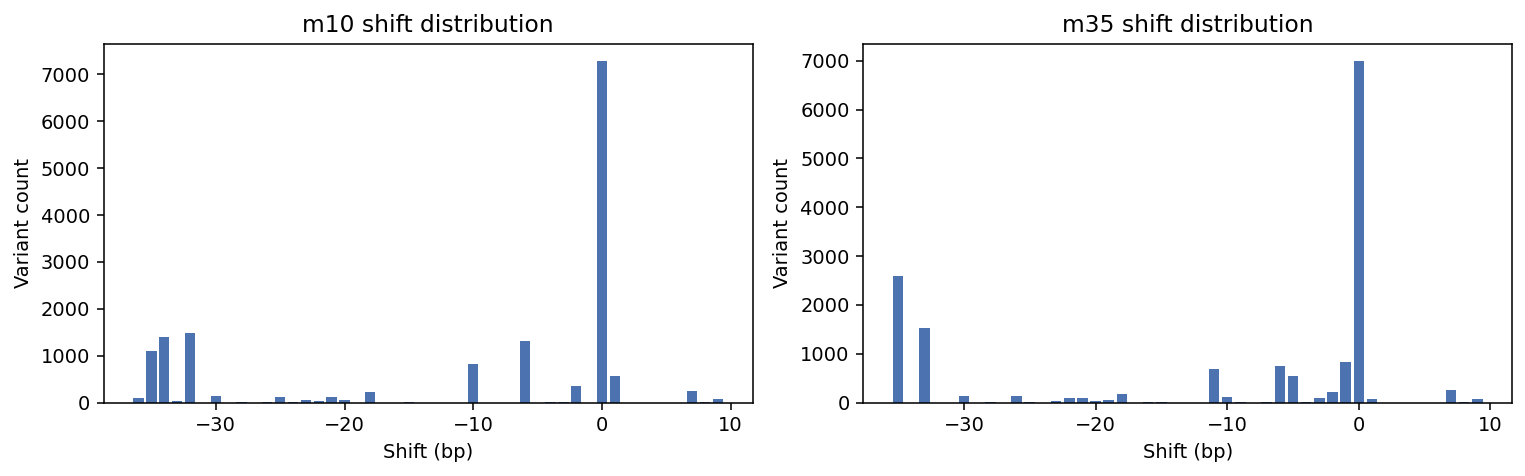

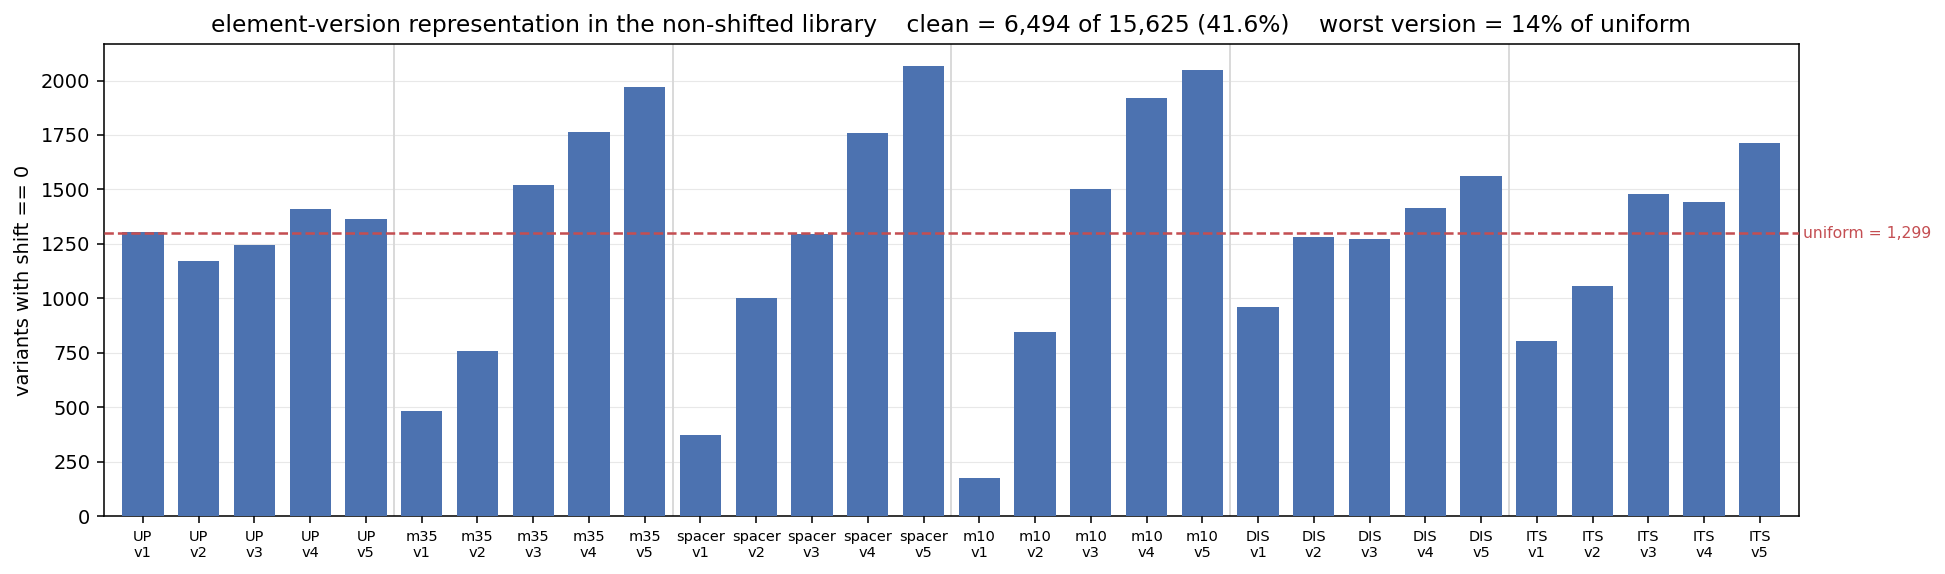

In [19]:
plot_shift_distributions(initial_scan)
plot_version_uniformity(initial_scan)


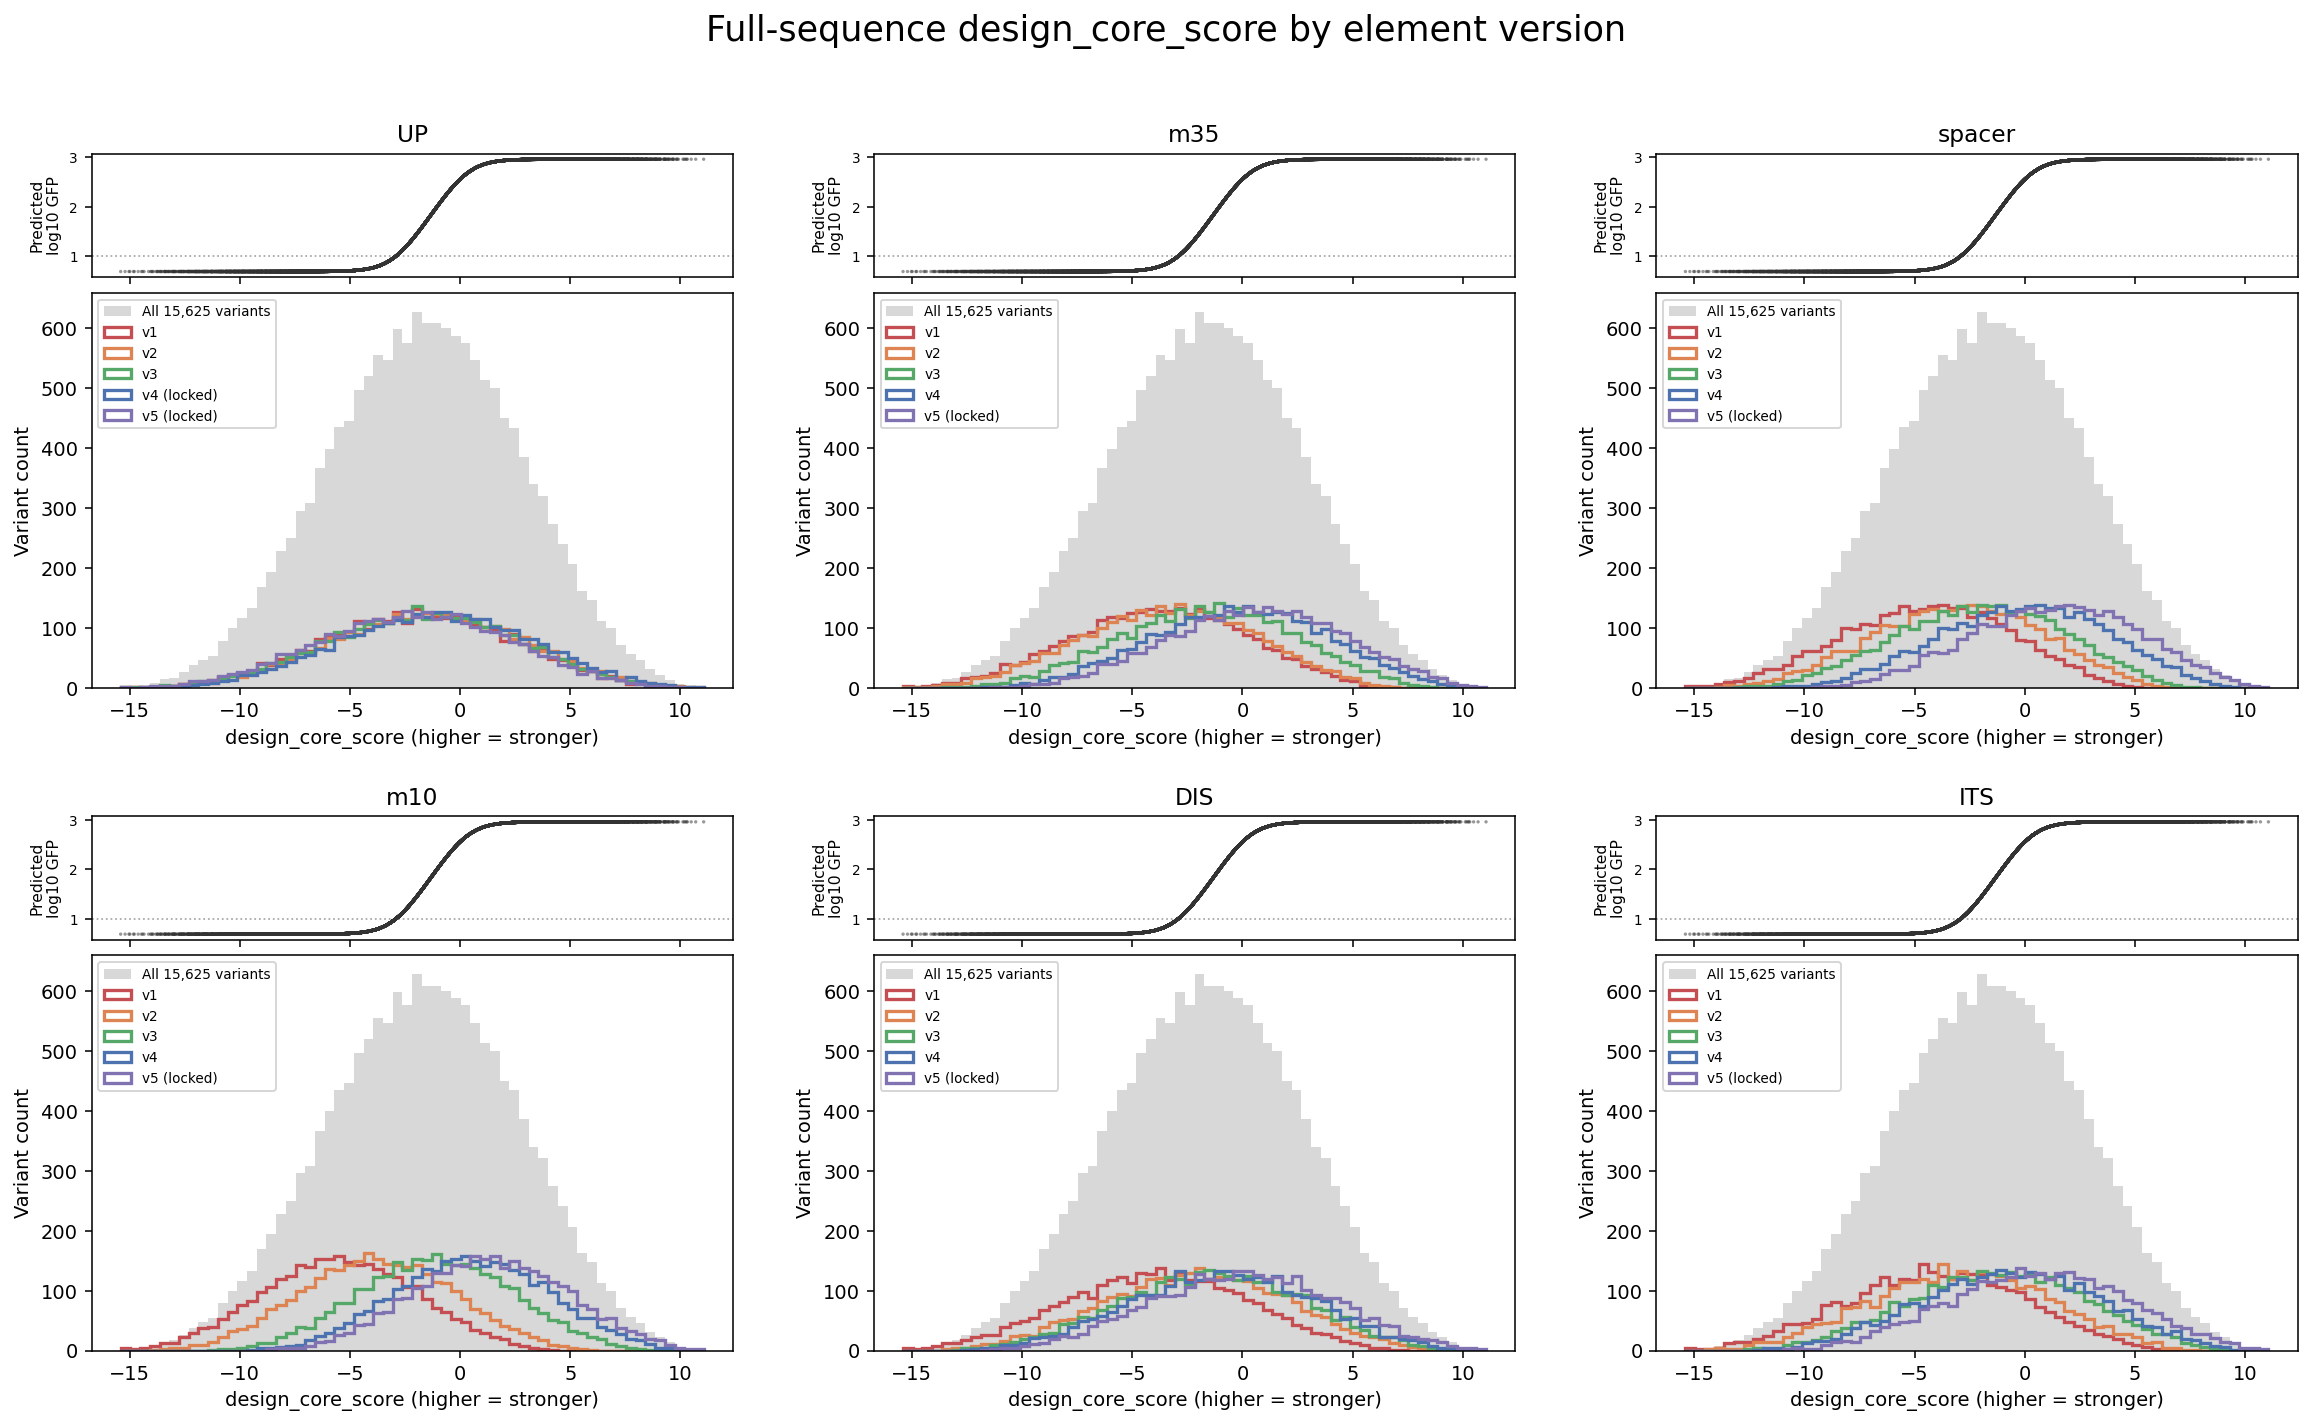

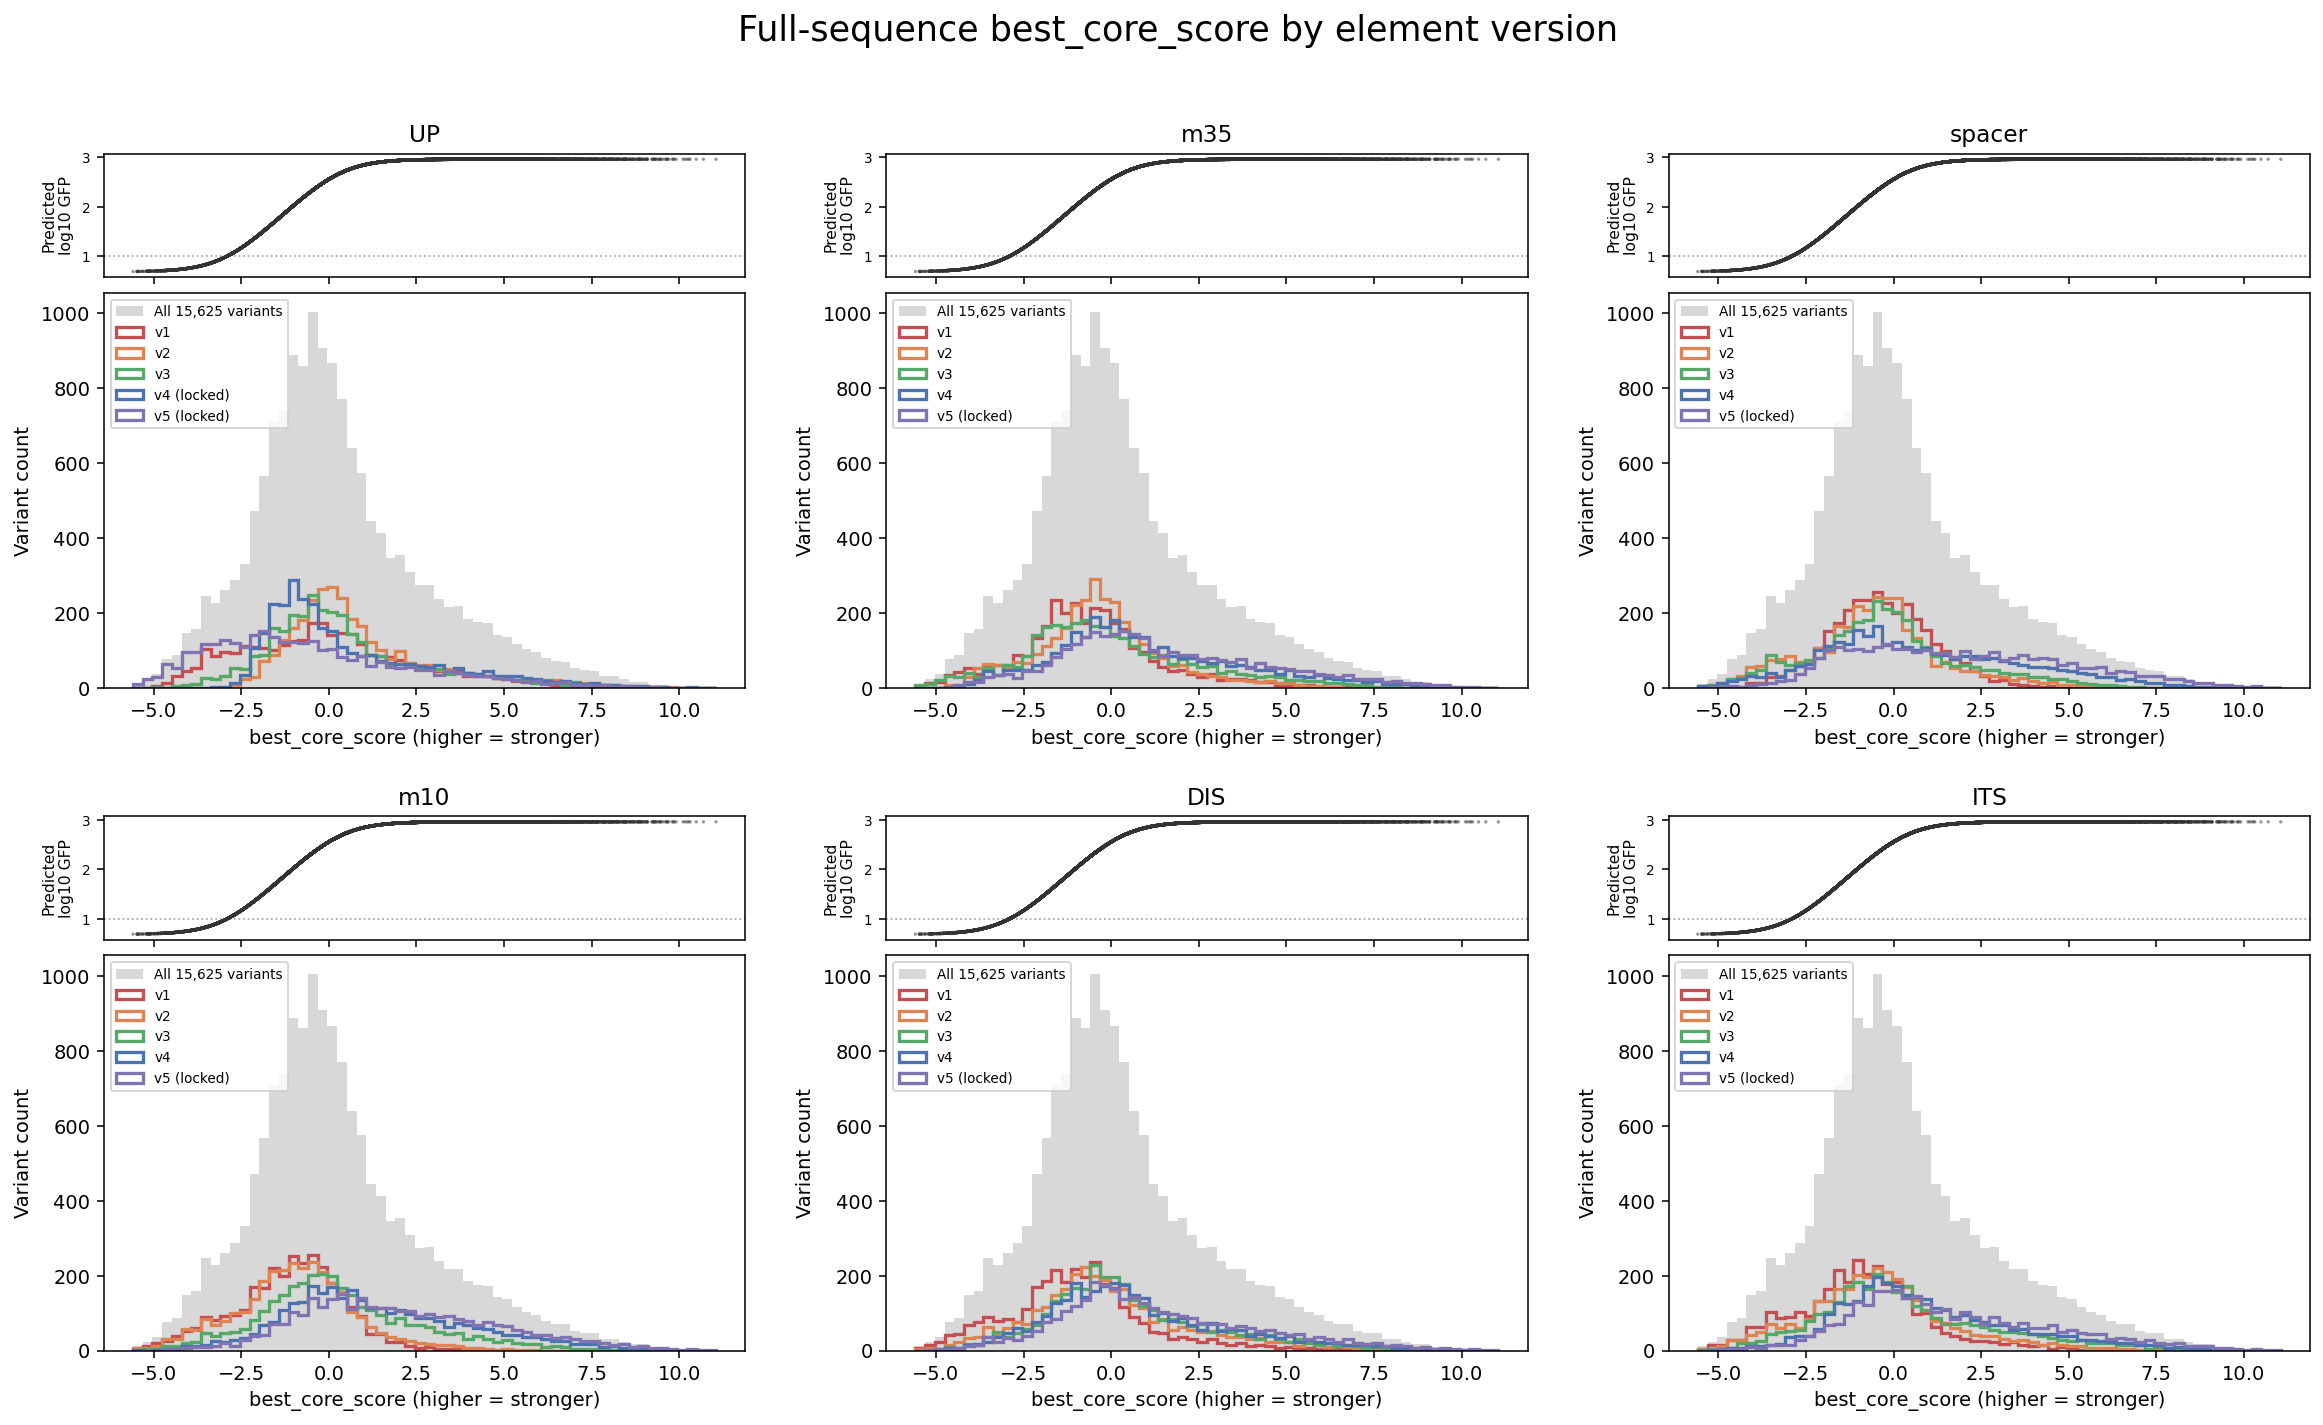

In [20]:
plot_element_version_energy_distributions(initial_scan, "design_core_score")
plot_element_version_energy_distributions(initial_scan, "best_core_score")


## Batch 5: dominant shift and conditional-risk diagnosis

診斷的對象是**當前 phase 那一欄**（`m10_shift` 或 `m35_shift`）所有 `shift != 0` 的 variants；
先找數量最多的 shift coordinate（`_dominant_shift`，超界只當作次要 tie-breaker），
再以 `P(dominant shift | element version)` 排名 driver。

Observed role 落在某個 design region 只用來提供 redesign evidence；不同 element model 的 raw delta energy不互相比較。最終 replacement 仍由完整 15,625 before/after validation 決定。


In [10]:
initial_diagnosis = r.diagnose_shift_drivers(
    scan=initial_scan,
    selected_elements=initial_elements,
    design_space=design_space,
    config=CONFIG,
)

print("Optimization phase:", initial_diagnosis["phase"])
print("Dominant shift coordinate:", initial_diagnosis["dominant_shift"])
display(initial_diagnosis["risk"].head(20))
display(initial_diagnosis["overlap"].head(30))


Optimization phase: m10
Dominant shift coordinate: -32


,phase,dominant_shift,element,version,design_unit_id,actionable,n_contexts,n_target_shift,conditional_shift_risk,overall_target_shift_rate,risk_enrichment,top_observed_role_on_design,top_overlap_n,top_overlap_fraction,top_role_median_delta_energy
0,m10,-32,UP,v3,v3,True,3125,1717,0.54944,0.109888,5.000000,m10,1717,1.0,4.227587
1,m10,-32,spacer,v1,v1,True,3125,537,0.17184,0.109888,1.563774,ITS,537,1.0,0.096119
2,m10,-32,m10,v1,v1,True,3125,502,0.16064,0.109888,1.461852,UP,0,0.0,NaN
3,m10,-32,DIS,v1,v1,True,3125,482,0.15424,0.109888,1.403611,UP,0,0.0,NaN
4,m10,-32,ITS,v1,v1,True,3125,473,0.15136,0.109888,1.377402,UP,0,0.0,NaN
5,m10,-32,spacer,v2,v2_v3_pair,True,3125,438,0.14016,0.109888,1.275480,ITS,438,1.0,0.498344
6,m10,-32,spacer,v3,v2_v3_pair,True,3125,425,0.13600,0.109888,1.237624,ITS,425,1.0,0.498344
7,m10,-32,ITS,v2,v2,True,3125,423,0.13536,0.109888,1.231800,UP,0,0.0,NaN
8,m10,-32,m35,v1,v1,True,3125,412,0.13184,0.109888,1.199767,DIS,412,1.0,0.095166
9,m10,-32,DIS,v2,v2,True,3125,388,0.12416,0.109888,1.129878,UP,0,0.0,NaN


,phase,dominant_shift,design_element,design_version,observed_role,n_target_contexts,overlap_n,overlap_fraction,median_within_model_delta_energy,max_within_model_delta_energy
0,m10,-32,UP,v3,spacer,1717,1717,1.0,1.987511,3.606649
1,m10,-32,UP,v3,m10,1717,1717,1.0,4.227587,5.398835
2,m10,-32,spacer,v1,ITS,537,537,1.0,0.096119,1.538639
3,m10,-32,spacer,v2,ITS,438,438,1.0,0.498344,1.360848
4,m10,-32,spacer,v3,ITS,425,425,1.0,0.498344,1.360848
5,m10,-32,m35,v1,DIS,412,412,1.0,0.095166,4.384254
6,m10,-32,m35,v1,ITS,412,412,1.0,0.043502,1.538639
7,m10,-32,m35,v3,DIS,387,387,1.0,0.630136,4.912249
8,m10,-32,m35,v3,ITS,387,387,1.0,0.096119,1.538639
9,m10,-32,m35,v2,DIS,341,341,1.0,0.338600,4.185877


## Batch 6: monotonic automated redesign with live progress and resume

每輪會 print iteration、phase（含 20% 閘門是 open 還是 closed）、目前 m10/m35 shifted rate、out-of-range count、dominant shift、driver units、每個 proposal 結果與接受/拒絕原因。

接受規則依 phase 而不同：

- **m10 階段**：objective `(m10 偏移數, m35 偏移數, 超界數, …)` 嚴格下降。
- **m35 階段**：先用 hard filter 剔除**任何讓 m10 偏移數上升**的 proposal（持平可以），
  再要求 objective `(m35 偏移數, m10 偏移數, 超界數, …)` 嚴格下降。

`search_progress.csv` 每輪多一欄 `m10_phase_gate_pass`，可以直接看出哪一輪跨過 20% 閘門切進 -35 階段、哪一輪又切回 m10。

執行期間會在 `OUT_DIR` 持續覆寫：

- `search_progress.csv`：每輪狀態的持續更新 DataFrame。
- `proposal_history_checkpoint.csv`：所有已測 single/double proposals。
- `current_elements_checkpoint.csv`：目前接受的 30 條 sequences。
- `current_validation.json`：目前 validation。
- `search_checkpoint.json`：state、最後完成輪數、stalled counter 與已測 proposals。

`progress_df` 也會在記憶體中每輪原地更新；手動 interrupt 後可直接 `display(progress_df.tail())`。

若中途停止 kernel，將 setup cell 的 `RUN_MODE` 改為 `"resume"`，並把 `RESUME_DIR` 指向原本的 output directory；Batch 6 會從下一個 iteration 繼續。每次 resume 的 `max_iterations` 是額外輪數，不是總累積上限。


In [11]:
redesigner = r.AutomatedRedesigner(
    design_space=design_space,
    scanner=scanner,
    gap_assignment=gap_assignment,
    config=CONFIG,
    out_dir=OUT_DIR,
    **SEARCH_SETTINGS,
)

# Mutated in place after every completed iteration. It remains available if
# this cell is manually interrupted.
progress_df = pd.DataFrame()

result = redesigner.run(
    initial_state=initial_state,
    initial_evaluation=(initial_elements, initial_scan, initial_summary),
    resume=(RUN_MODE == "resume"),
    reset_stalled_on_resume=True,
    progress_df=progress_df,
    verbose=True,
)

print("Success:", result.success)
print("Stop reason:", result.stop_reason)
print("Saved to:", result.out_dir)
display(pd.DataFrame([result.final_summary]))
display(progress_df)


Batch6 search:   0%|          | 0/50 [00:00<?, ?it/s, m10=66.4%, m35=72.2%, phase=m10, stalled=0/60]


[Iteration 1] phase=m10 (m10 gate<=20% closed) | m10 shifted=66.44% out=9463 max_abs=36 | m35 shifted=72.23% out=9648 max_abs=35 | stalled=0/60
  dominant m10_shift=-32 | drivers=['UP:v3', 'spacer:v1', 'spacer:v2_v3_pair']
  driver pools: ['UP:v3 remaining=499/499', 'spacer:v1 remaining=499/499', 'spacer:v2_v3_pair remaining=479/479']
    evaluating single: UP:v3->1
      m10=66.59% (out=9433) | m35=72.66% (out=9667)
    evaluating single: UP:v3->2
      m10=65.57% (out=9132) | m35=70.66% (out=9401)
    evaluating single: spacer:v1->1
      m10=66.03% (out=9338) | m35=71.96% (out=9527)
    evaluating single: spacer:v1->2
      m10=66.44% (out=9546) | m35=72.87% (out=9734)
    evaluating single: spacer:v2_v3_pair->1
      m10=66.59% (out=9478) | m35=72.65% (out=9597)
    evaluating single: spacer:v2_v3_pair->2
      m10=68.01% (out=9808) | m35=71.56% (out=9773)
    evaluating double: UP:v3->2;spacer:v1->1
      m10=65.11% (out=8989) | m35=70.38% (out=9267)
    evaluating double: UP:v3-

Batch6 search:   2%|▏         | 1/50 [00:31<25:38, 31.40s/it, m10=65.1%, m35=70.4%, phase=m10, stalled=0/60]

  ACCEPT double: UP:v3->2;spacer:v1->1 | m10=65.11%, m35=70.38%

[Iteration 2] phase=m10 (m10 gate<=20% closed) | m10 shifted=65.11% out=8989 max_abs=42 | m35 shifted=70.38% out=9267 max_abs=43 | stalled=0/60
  dominant m10_shift=-34 | drivers=['UP:v2', 'spacer:v2_v3_pair', 'm35:v1']
  driver pools: ['UP:v2 remaining=499/499', 'spacer:v2_v3_pair remaining=479/479', 'm35:v1 remaining=115/115']
    evaluating single: UP:v2->1
      m10=63.53% (out=8461) | m35=68.72% (out=8853)
    evaluating single: UP:v2->2
      m10=63.17% (out=8459) | m35=68.37% (out=8764)
    evaluating single: spacer:v2_v3_pair->1
      m10=65.26% (out=9001) | m35=70.77% (out=9192)
    evaluating single: spacer:v2_v3_pair->2
      m10=67.12% (out=9507) | m35=69.97% (out=9485)
    evaluating single: m35:v1->1
      m10=65.70% (out=8995) | m35=70.40% (out=9279)
    evaluating single: m35:v1->2
      m10=65.03% (out=8886) | m35=70.31% (out=9200)
    evaluating double: UP:v2->2;m35:v1->2
      m10=63.10% (out=8326) | m3

Batch6 search:   4%|▍         | 2/50 [01:00<23:53, 29.87s/it, m10=63.1%, m35=68.4%, phase=m10, stalled=0/60]

...

  ACCEPT double: UP:v1->2;m35:v1->0 | m10=61.85%, m35=67.67%

[Iteration 4] phase=m10 (m10 gate<=20% closed) | m10 shifted=61.85% out=8099 max_abs=42 | m35 shifted=67.67% out=8547 max_abs=43 | stalled=0/60
  dominant m10_shift=-42 | drivers=['UP:v3', 'UP:v2', 'm35:v1']
  driver pools: ['UP:v3 remaining=499/499', 'UP:v2 remaining=499/499', 'm35:v1 remaining=115/115']
    evaluating single: UP:v3->0
      m10=62.76% (out=8448) | m35=69.25% (out=8807)
    evaluating single: UP:v3->1
      m10=62.55% (out=8279) | m35=69.08% (out=8691)
    evaluating single: UP:v2->0
      m10=63.79% (out=8629) | m35=69.68% (out=9050)
    evaluating single: UP:v2->1
      m10=62.20% (out=8101) | m35=68.02% (out=8636)
    evaluating single: m35:v1->1
      m10=62.71% (out=8103) | m35=67.67% (out=8559)
    evaluating single: m35:v1->2
      m10=61.90% (out=7970) | m35=67.67% (out=8472)
    evaluating double: m35:v1->2;UP:v2->1
      m10=62.22% (out=7979) | m35=68.02% (out=8561)
    evaluating double: m35:v1->

Batch6 search:   8%|▊         | 4/50 [01:43<18:32, 24.18s/it, m10=61.8%, m35=67.7%, phase=m10, stalled=1/60]

  NO ACCEPTED MOVE: strict objective did not improve (stalled=1/60).

[Iteration 5] phase=m10 (m10 gate<=20% closed) | m10 shifted=61.85% out=8099 max_abs=42 | m35 shifted=67.67% out=8547 max_abs=43 | stalled=1/60
  dominant m10_shift=-42 | drivers=['UP:v3', 'UP:v2', 'm35:v1']
  driver pools: ['UP:v3 remaining=497/499', 'UP:v2 remaining=497/499', 'm35:v1 remaining=113/115']
    evaluating single: UP:v3->3
      m10=63.46% (out=8381) | m35=69.36% (out=8856)
    evaluating single: UP:v3->4
      m10=61.93% (out=8177) | m35=68.12% (out=8634)
    evaluating single: UP:v2->3
      m10=62.55% (out=8304) | m35=69.52% (out=8758)
    evaluating single: UP:v2->4
      m10=64.35% (out=8688) | m35=70.69% (out=9114)
    evaluating single: m35:v1->3
      m10=61.37% (out=8085) | m35=67.67% (out=8382)
    evaluating single: m35:v1->4


Batch6 search:   8%|▊         | 4/50 [01:51<21:20, 27.84s/it, m10=61.8%, m35=67.7%, phase=m10, stalled=1/60]


KeyboardInterrupt: 

## Batch 7: final design and audit tables

`final_elements.csv` 是最後保留的 30 條 element sequences；`proposal_history.csv` 同時保留 accepted 與 rejected moves，方便追蹤為何某次替換沒有被採用。


,element,version,design_unit_id,sequence,energy,energy_bin,selection_mode,locked,in_database
0,DIS,v1,v1,GCGTCGCC,-2.173586,1.0,database_bin,False,True
1,DIS,v2,v2,GGGTAACT,-0.736546,2.0,database_bin,False,True
2,DIS,v3,v3,TGTGCTAG,0.700236,3.0,database_bin,False,True
3,DIS,v4,v4,ATTGGTTA,2.137798,4.0,database_bin,False,True
4,DIS,v5,locked_v5,TTTTATTA,2.856126,4.0,locked_consensus,True,True
5,ITS,v1,v1,GGAGCCGCGC,-1.061163,1.0,database_bin,False,True
6,ITS,v2,v2,AAGTCGTCGA,-0.339596,2.0,database_bin,False,True
7,ITS,v3,v3,CTAACGAACA,0.381757,3.0,database_bin,False,True
8,ITS,v4,v4,CGAAAAATTG,1.103104,4.0,database_bin,False,True
9,ITS,v5,locked_v5,CAAAAAAAAG,1.452267,4.0,locked_consensus,True,True


,phase,dominant_shift,element,version,design_unit_id,actionable,n_contexts,n_target_shift,conditional_shift_risk,overall_target_shift_rate,risk_enrichment,top_observed_role_on_design,top_overlap_n,top_overlap_fraction,top_role_median_delta_energy
0,m10,-35,UP,v4,locked_v4,False,3125,651,0.20832,0.05824,3.576923,spacer,651,1.0,2.857959
1,m10,-35,spacer,v1,v1,True,3125,575,0.18400,0.05824,3.159341,ITS,575,1.0,-0.016164
2,m10,-35,DIS,v1,v1,True,3125,347,0.11104,0.05824,1.906593,UP,0,0.0,NaN
3,m10,-35,m35,v1,v1,True,3125,307,0.09824,0.05824,1.686813,DIS,307,1.0,0.937935
4,m10,-35,m10,v2,v2,True,3125,293,0.09376,0.05824,1.609890,UP,0,0.0,NaN
5,m10,-35,m35,v2,v2,True,3125,285,0.09120,0.05824,1.565934,DIS,285,1.0,1.020067
6,m10,-35,ITS,v1,v1,True,3125,285,0.09120,0.05824,1.565934,UP,0,0.0,NaN
7,m10,-35,m10,v1,v1,True,3125,278,0.08896,0.05824,1.527473,UP,0,0.0,NaN
8,m10,-35,ITS,v2,v2,True,3125,240,0.07680,0.05824,1.318681,UP,0,0.0,NaN
9,m10,-35,DIS,v2,v2,True,3125,210,0.06720,0.05824,1.153846,UP,0,0.0,NaN


,phase,dominant_shift,design_element,design_version,observed_role,n_target_contexts,overlap_n,overlap_fraction,median_within_model_delta_energy,max_within_model_delta_energy
0,m10,-35,UP,v4,spacer,651,651,1.0,2.857959,2.857959
1,m10,-35,UP,v4,m10,651,651,1.0,2.745711,3.950652
2,m10,-35,UP,v4,DIS,651,651,1.0,1.322906,3.719393
3,m10,-35,spacer,v1,ITS,575,575,1.0,-0.016164,1.020993
4,m10,-35,m35,v1,DIS,307,307,1.0,0.937935,3.248146
5,m10,-35,m35,v1,ITS,307,307,1.0,0.169899,1.157317
6,m10,-35,m35,v2,DIS,285,285,1.0,1.020067,3.254814
7,m10,-35,m35,v2,ITS,285,285,1.0,0.284694,1.272112
8,m10,-35,UP,v5,spacer,203,203,1.0,5.479852,5.479852
9,m10,-35,UP,v5,m10,203,203,1.0,-1.788290,-0.583348


,anchor,shifted_count,shifted_rate,out_of_range_count,max_abs_shift,pass
0,m10,4532,0.290048,4214,43,False
1,m35,6954,0.445056,4211,43,False


phase=m10 | m10 gate (<= 20%) closed | m10 29.00% pass=False | m35 44.51% pass=False | global pass=False


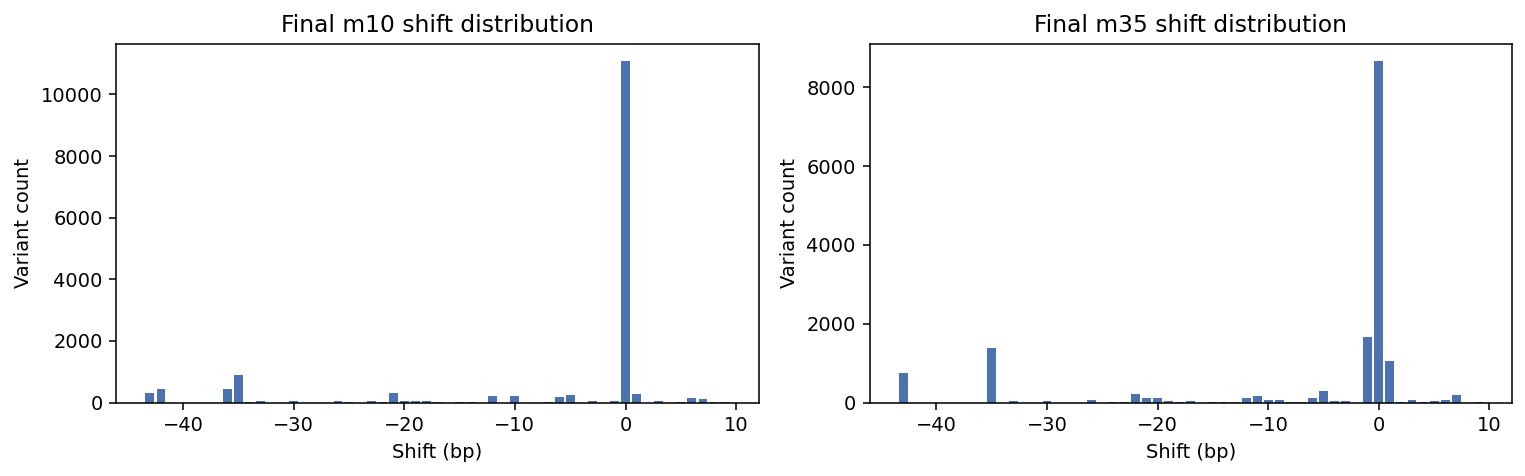

,iteration,phase,proposal_type,changes,valid,error,accepted,n_variants,max_allowed_shifted_count,target_margin_positive_count,...,m10_max_abs_shift,m10_validation_pass,m35_shifted_count,m35_shifted_rate,m35_out_of_range_count,m35_max_abs_shift,m35_validation_pass,global_validation_pass,m10_phase_gate_pass,objective
6,1,m10,double,m10:v4->2;m10:v3->1,True,NaN,True,15625,1562,4876,...,36,False,10583,0.677312,6476,35,False,False,False,"(8804, 10583, 12712, 36, 35)"
19,2,m10,single,m35:v1->2,True,NaN,True,15625,1562,4726,...,36,False,10733,0.686912,6997,35,False,False,False,"(8733, 10733, 13556, 36, 35)"
33,3,m10,single,DIS:v3->2,True,NaN,True,15625,1562,4902,...,36,False,10577,0.676928,7004,35,False,False,False,"(8461, 10577, 13638, 36, 35)"
46,4,m10,single,DIS:v4->1,True,NaN,True,15625,1562,5061,...,36,False,10440,0.668160,6800,35,False,False,False,"(8152, 10440, 13316, 36, 35)"
76,6,m10,double,m35:v1->4;m10:v2->3,True,NaN,True,15625,1562,5122,...,36,False,10391,0.665024,6999,35,False,False,False,"(7937, 10391, 13801, 36, 35)"
87,7,m10,single,UP:v2->2,True,NaN,True,15625,1562,5223,...,42,False,10276,0.657664,6736,43,False,False,False,"(7767, 10276, 13367, 42, 43)"
103,8,m10,single,m35:v4->2,True,NaN,True,15625,1562,5531,...,42,False,9953,0.636992,6657,43,False,False,False,"(7604, 9953, 13208, 42, 43)"
156,12,m10,single,m35:v1->7,True,NaN,True,15625,1562,5500,...,42,False,9984,0.638976,6572,43,False,False,False,"(7537, 9984, 13110, 42, 43)"
174,13,m10,double,ITS:v1->1;spacer:v1->2,True,NaN,True,15625,1562,5737,...,42,False,9778,0.625792,6269,43,False,False,False,"(7181, 9778, 12516, 42, 43)"
202,15,m10,double,spacer:v1->3;UP:v1->4,True,NaN,True,15625,1562,6199,...,42,False,9228,0.590592,5766,43,False,False,False,"(6752, 9228, 11527, 42, 43)"


In [ ]:
display(result.final_elements)
display(result.final_risk.head(20))
display(result.final_overlap.head(30))

display(shift_summary_table(result.final_summary))
print(phase_status_line(result.final_summary))
plot_shift_distributions(result.final_scan, title_prefix="Final ")

accepted = result.proposals[result.proposals["accepted"]] if len(result.proposals) else result.proposals
display(accepted)


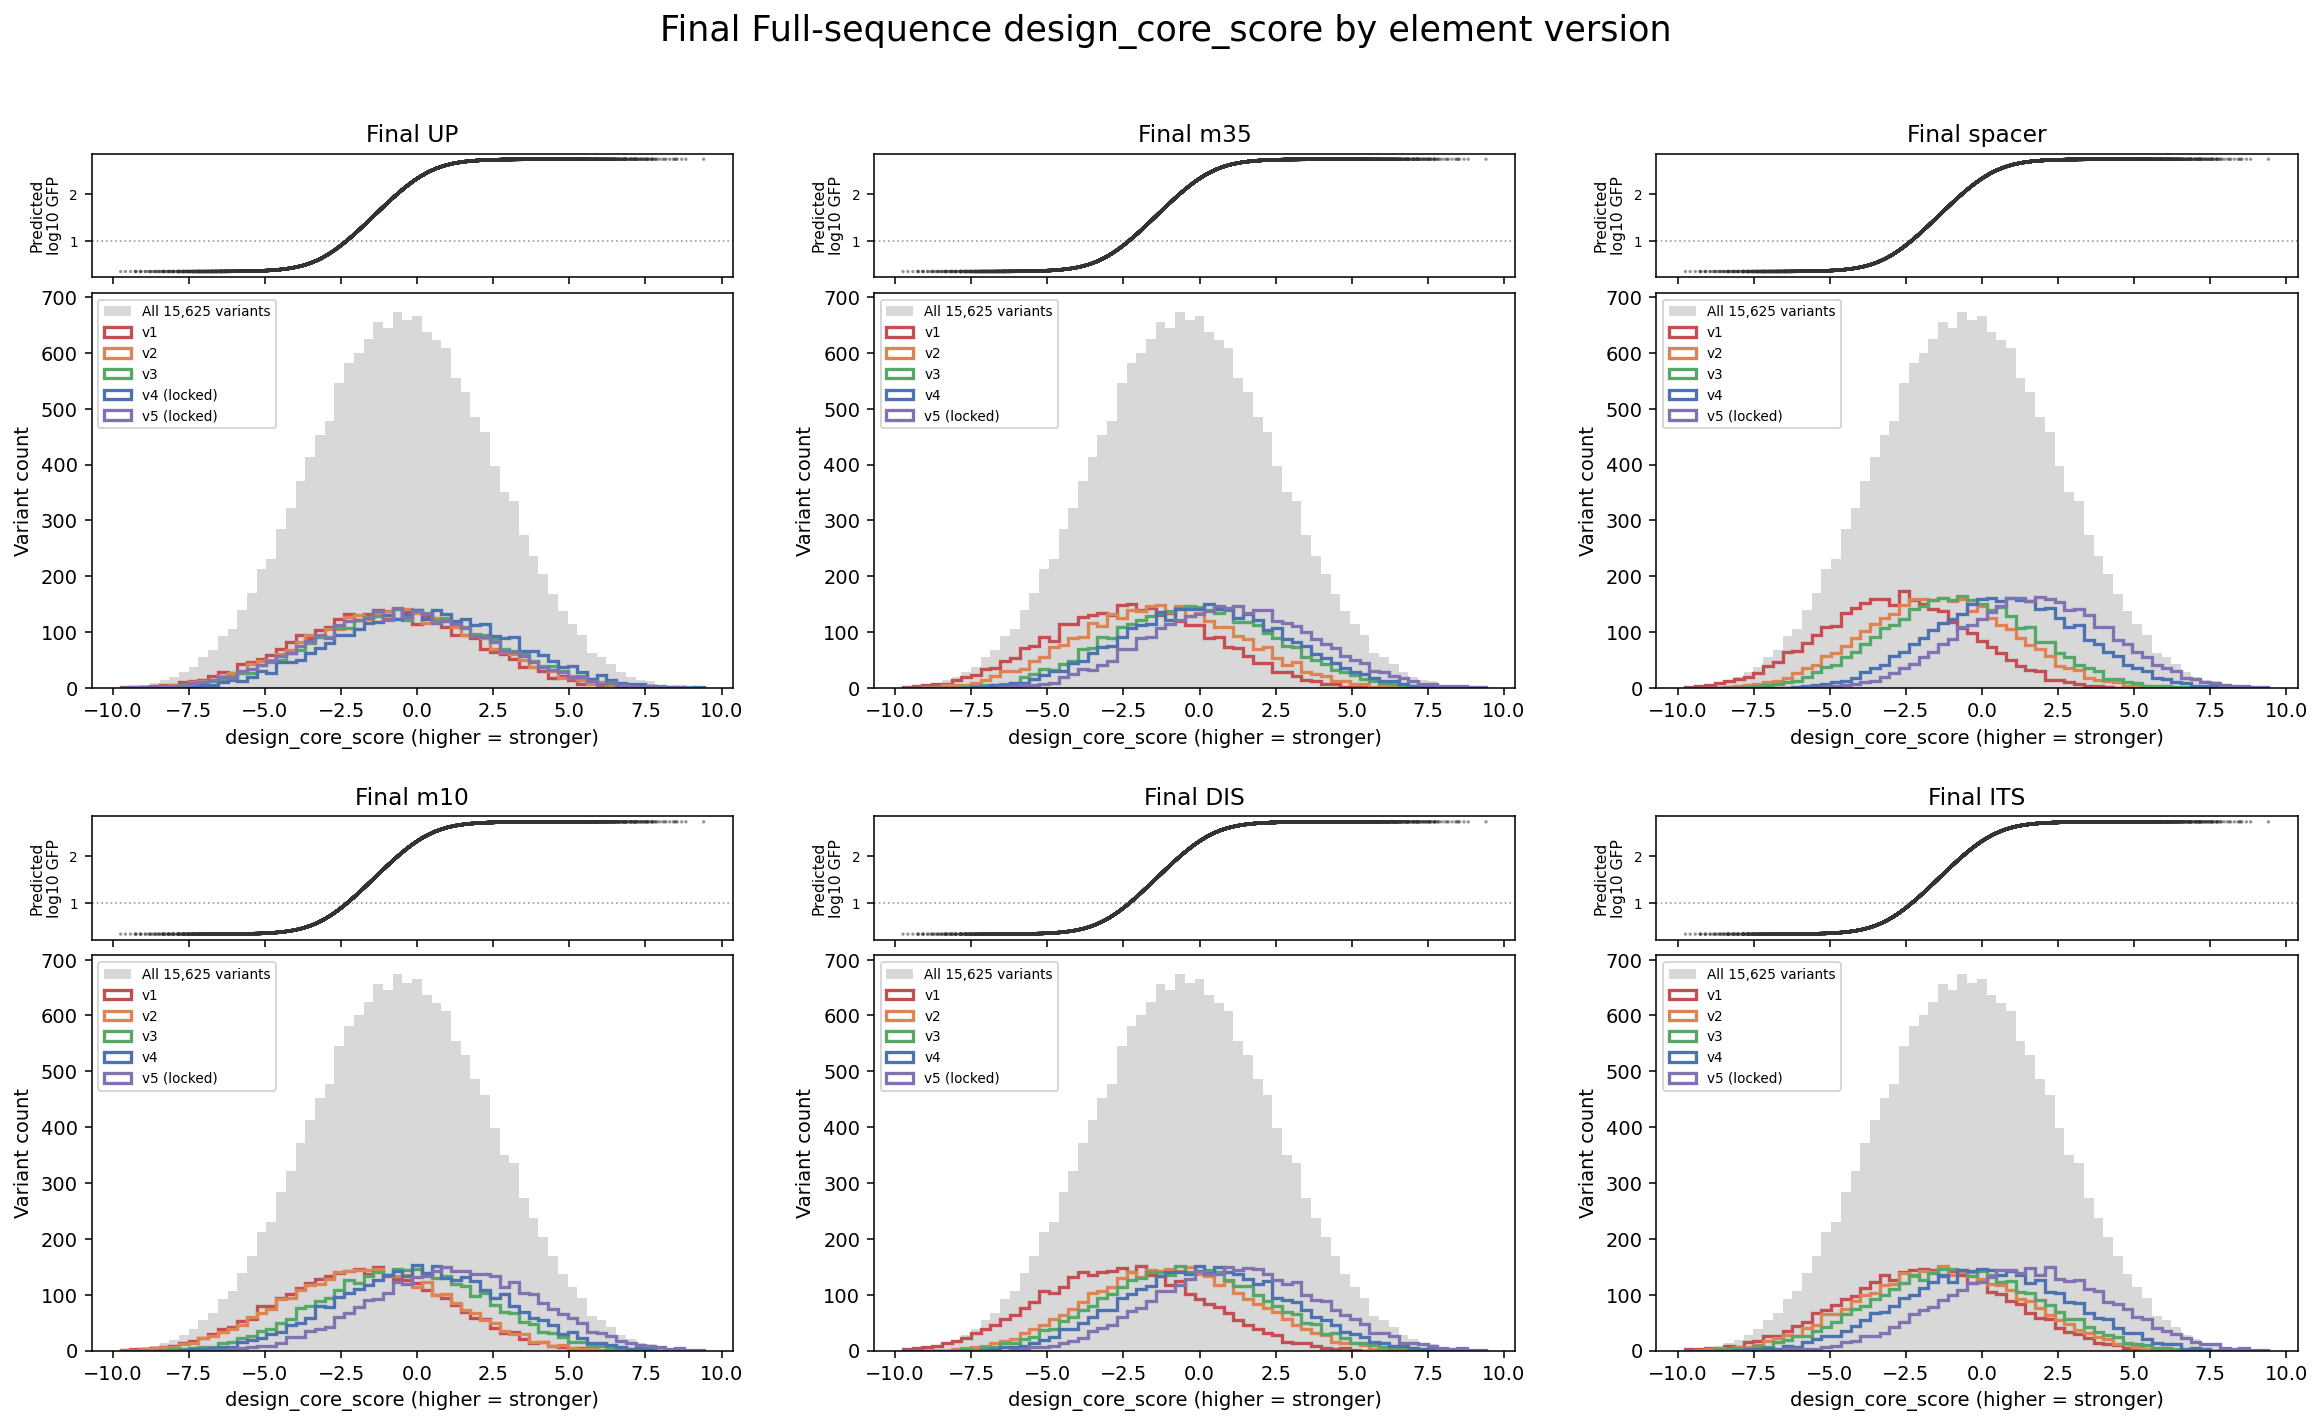

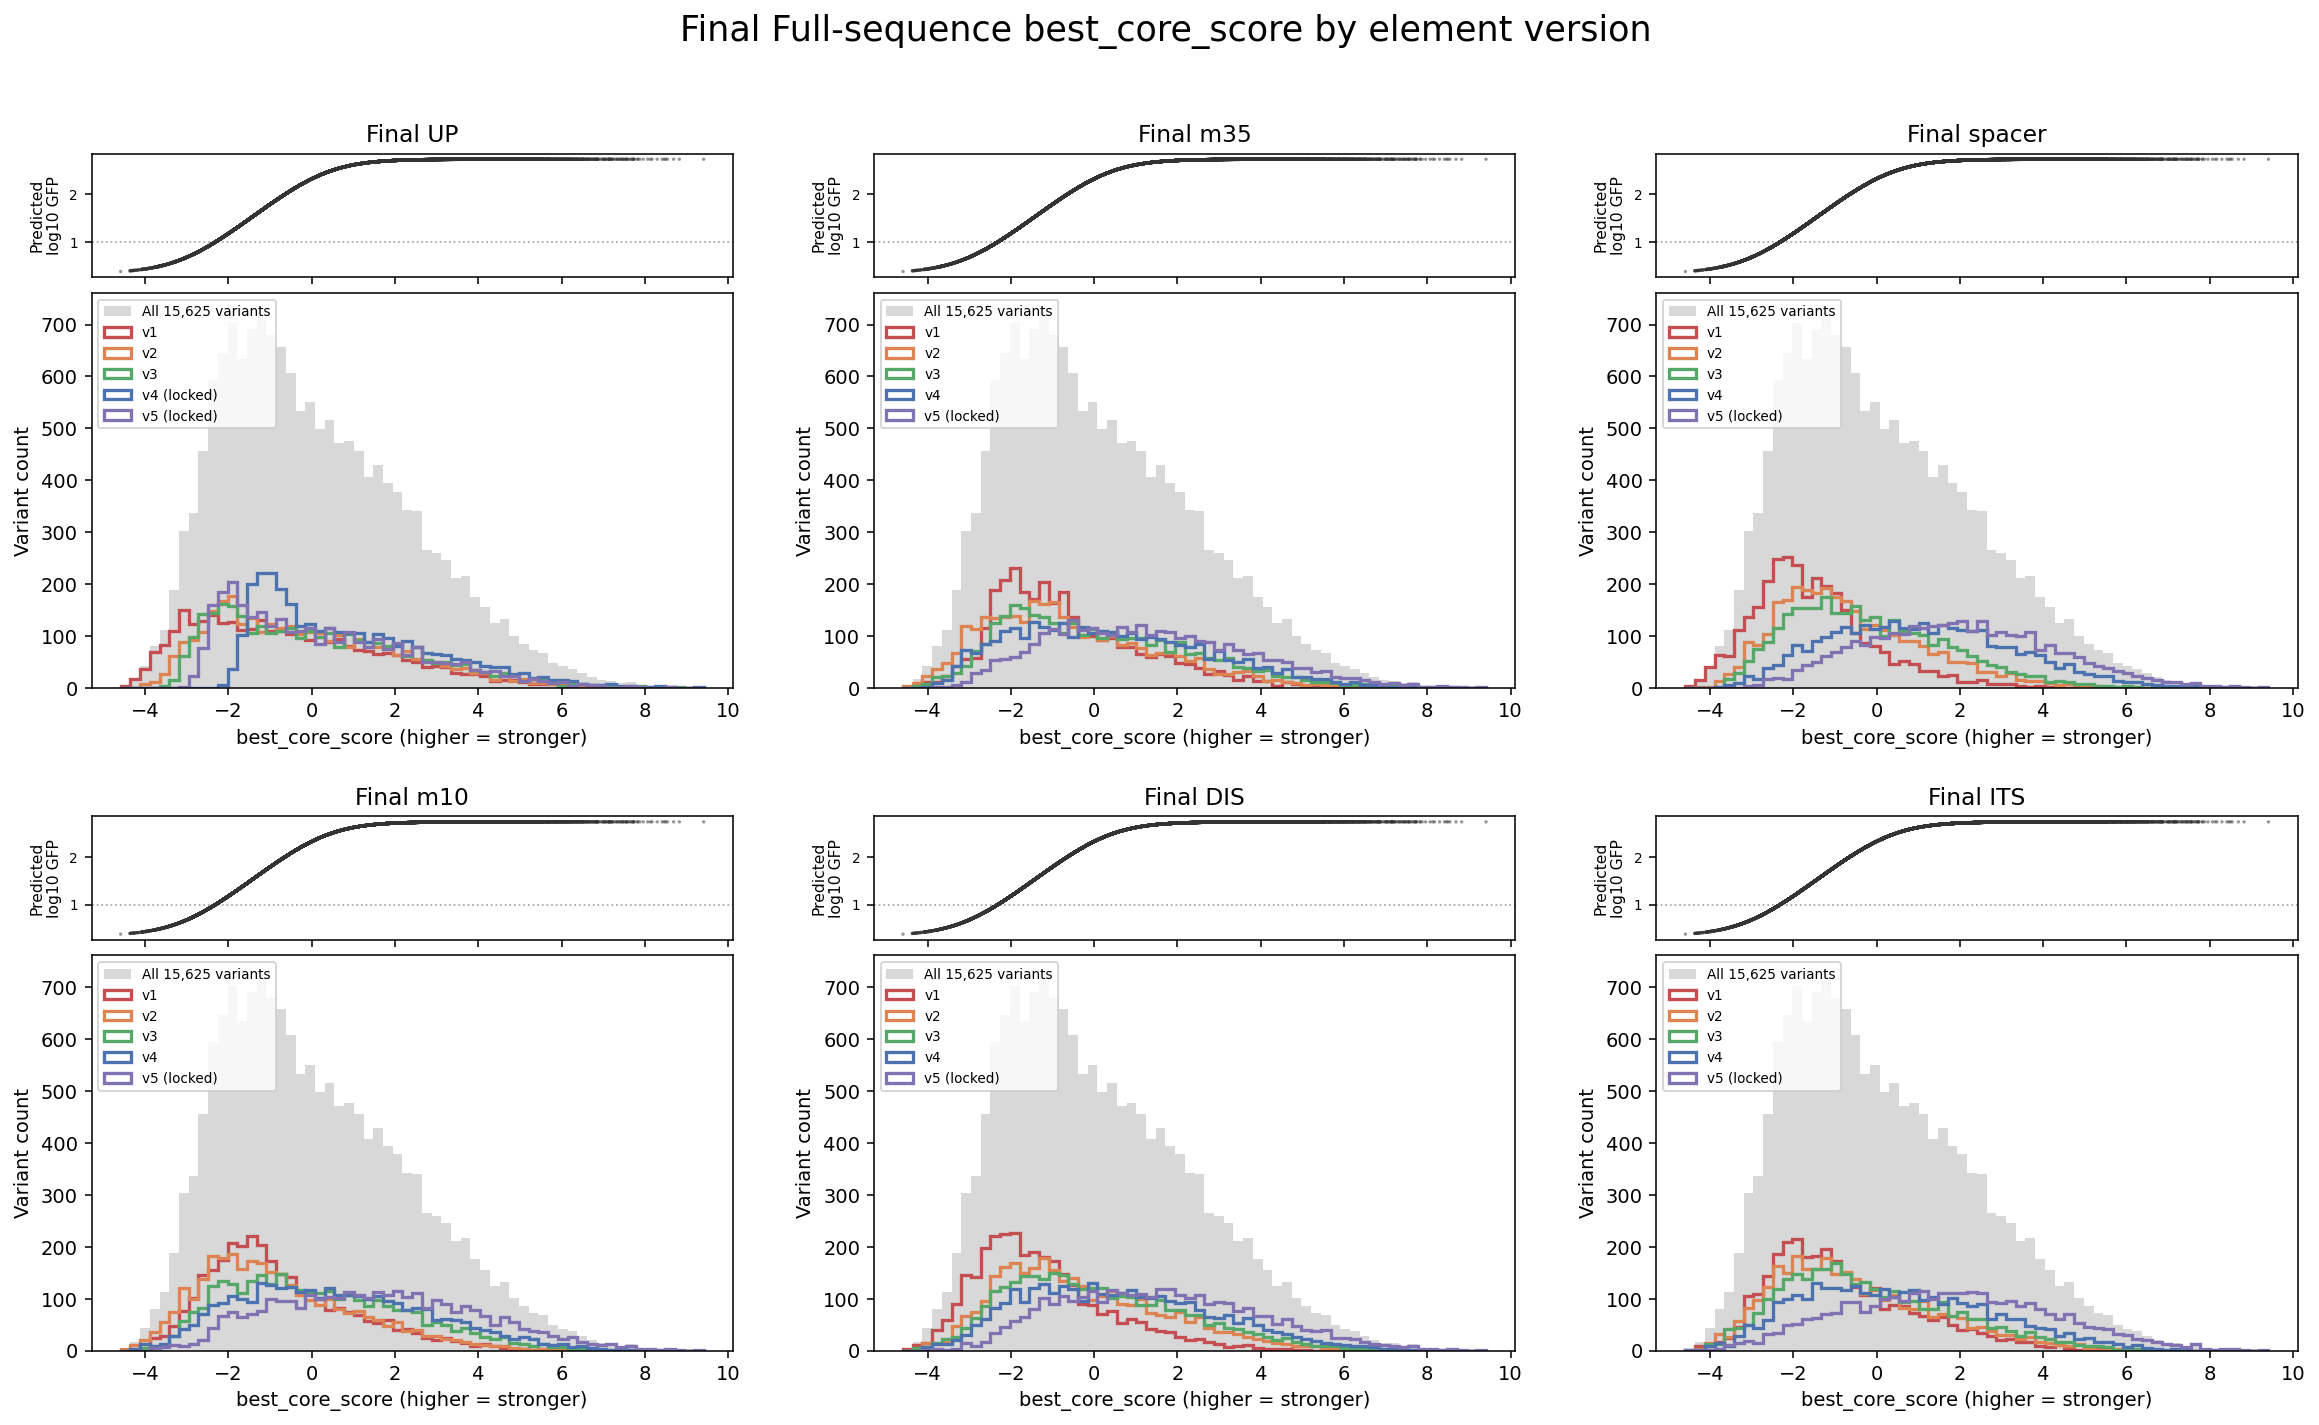

In [ ]:
plot_element_version_energy_distributions(result.final_scan, "design_core_score", title_prefix="Final ")
plot_element_version_energy_distributions(result.final_scan, "best_core_score", title_prefix="Final ")
plot_version_uniformity(result.final_scan, title_prefix="Final ")


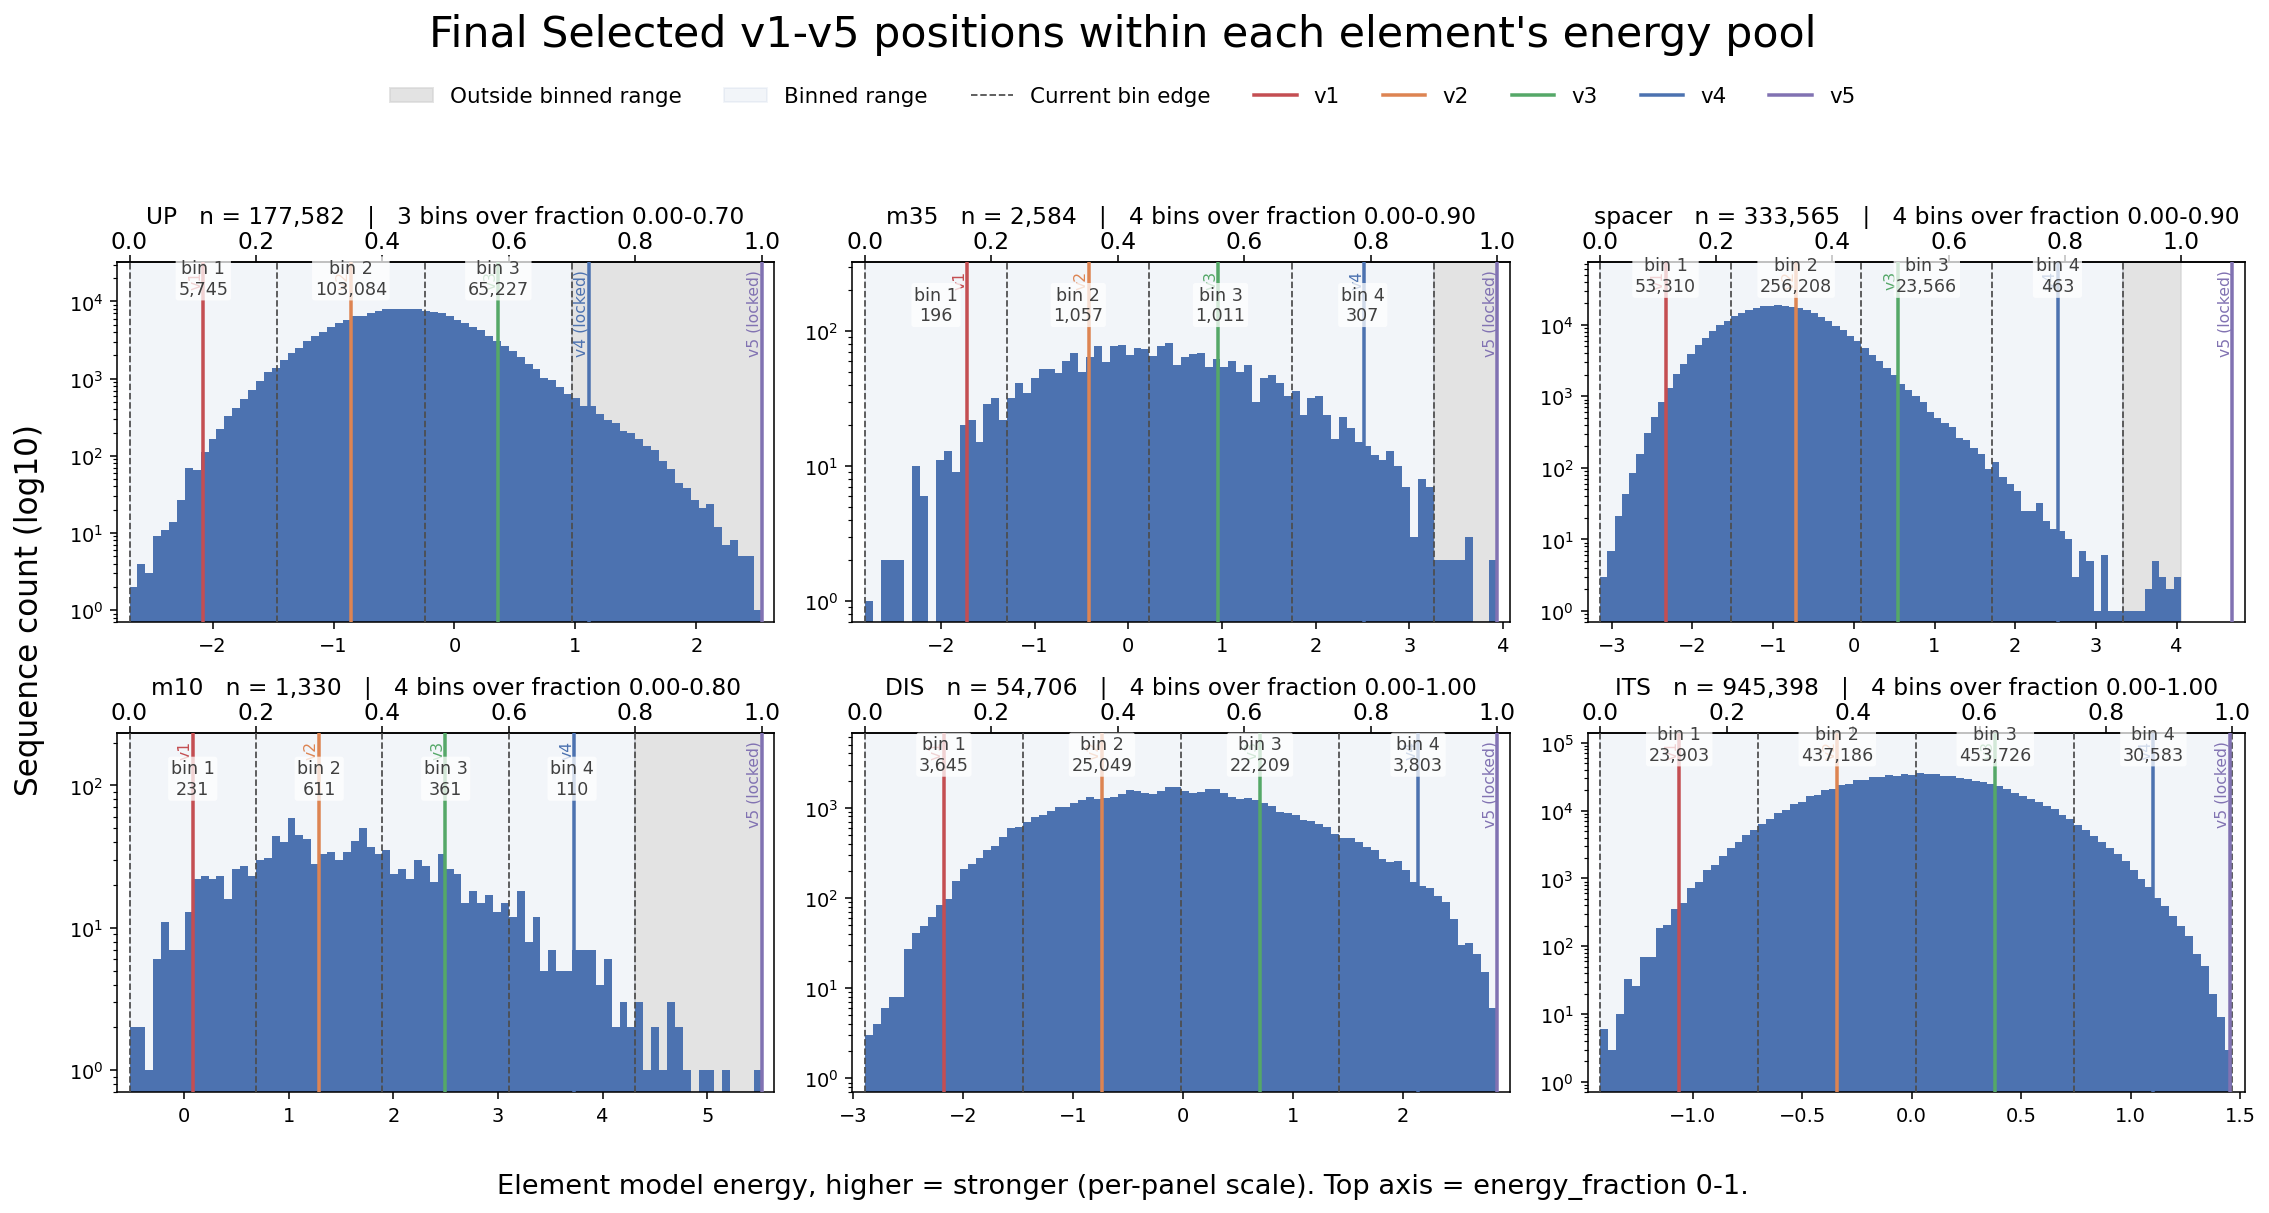

In [ ]:
plot_element_positions(result.final_elements, scored_pools, CONFIG, title_prefix="Final ")


## Batch 8: standardised output for the assembly step

Writes `outputs/01_final_design.csv` -- the 69 nt promoter only, no BG5/BG3.
This cell is self-contained: it re-reads the newest finished design run
from disk, so it can be run without re-executing the search above.

In [ ]:
# === Batch 8: standardised design table (01_final_design.csv) ===
# Emits the 69 nt promoter only. BG5/BG3, RE sites and the barcode are added
# once, for every source, by 06_assemble.ipynb.
import json

import pandas as pd

# The run this notebook just produced - not "whichever directory sorts last".
# latest_design_run() picks the newest name that HAS a final_scan_15625.csv, so
# a search that was interrupted (its directory exists but never finished) makes
# it reach silently back to an older, unrelated design and export that instead.
RUN_DIR = (OUT_DIR if (OUT_DIR / "final_scan_15625.csv").exists()
           else latest_design_run("final_scan_15625.csv"))
if RUN_DIR != OUT_DIR:
    print(f"WARNING: {OUT_DIR.name} has no final_scan_15625.csv, "
          f"falling back to {RUN_DIR.name}")
print("reading design run:", RUN_DIR.name)

scan = pd.read_csv(require(RUN_DIR / "final_scan_15625.csv", "design scan"))
cfg = json.loads(require(RUN_DIR / "run_config.json", "run config").read_text(encoding="utf-8"))
BG5 = cfg["design_config"]["bg5"]
BG3 = cfg["design_config"]["bg3"]
print(f"run bg5={len(BG5)} nt, bg3={len(BG3)} nt, full_sequence={scan['full_sequence'].str.len().unique().tolist()} nt")

# The flanks this run was scanned with must really be the flanks on the sequence,
# otherwise the slice below would silently cut into the promoter.
if not scan["full_sequence"].str.startswith(BG5).all():
    raise ValueError("some full_sequence rows do not start with the run's bg5")
if not scan["full_sequence"].str.endswith(BG3).all():
    raise ValueError("some full_sequence rows do not end with the run's bg3")

promoter = scan["full_sequence"].str[len(BG5): -len(BG3)]

# Independent check: the stripped promoter must equal the designed elements
# concatenated in order, so a layout change upstream cannot pass unnoticed.
rebuilt = (
    scan["UP_seq"] + scan["gap_3bp"] + scan["m35_seq"] + scan["spacer_seq"]
    + scan["m10_seq"] + scan["DIS_seq"] + scan["ITS_seq"]
)
if not promoter.equals(rebuilt):
    bad = int((promoter != rebuilt).sum())
    raise ValueError(f"{bad} promoters do not match UP+gap+m35+spacer+m10+DIS+ITS")

lengths = sorted(promoter.str.len().unique())
print("promoter length(s):", lengths)
if len(lengths) != 1:
    raise ValueError(f"designed promoters must all be one length, got {lengths}")

KEEP = [
    "variant_id", "gap_3bp",
    "UP_version", "m35_version", "spacer_version", "m10_version", "DIS_version", "ITS_version",
    "UP_seq", "m35_seq", "spacer_seq", "m10_seq", "DIS_seq", "ITS_seq",
    "UP_design_energy", "m35_design_energy", "spacer_design_energy",
    "m10_design_energy", "DIS_design_energy", "ITS_design_energy",
    "design_spacer_len", "design_m35_start", "design_m10_start", "design_channel",
    "observed_spacer_len", "observed_m35_start", "observed_m10_start",
    "m35_shift", "m10_shift", "spacer_length_shift",
    "design_core_score", "best_core_score", "strongest_non_target_core_score",
    "target_margin_core_score", "best_minus_design_core_score",
    "design_predicted_log10_gfp", "best_predicted_log10_gfp",
]
design = scan[KEEP].copy()
design["promoter_sequence"] = promoter
design["design_run"] = RUN_DIR.name
design["design_bg5"] = BG5
design["design_bg3"] = BG3

# A designed variant is only clean if the model reads the register it was
# designed for; that is the whole point of the recursive search.
register_ok = (design["m35_shift"] == 0) & (design["m10_shift"] == 0)
design["register_clean"] = register_ok
print(f"register_clean: {int(register_ok.sum())} / {len(design)}")

out = standardize(
    design,
    source="assembled",
    candidate_id="DES-" + design["variant_id"].astype(str),
)
out.to_csv(RELEASE_OUT / "01_final_design.csv", index=False)
print(f"\nwrote {RELEASE_OUT / '01_final_design.csv'}  {out.shape}")
print(out[STD_COLS].head(3).to_string(index=False))
print("\nqc_pass:", int(out["qc_pass"].sum()), "/", len(out))
